# Predicción del riesgo de impago de clientes

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Aprendizaje supervisado · Clasificación binaria

---

## Objetivo

Construir un modelo de clasificación binaria que estime, para cada cliente de una cartera, la
**probabilidad de pertenecer al grupo de alto riesgo de impago**, y convertir esa probabilidad
en una decisión operativa (marcar / no marcar) mediante un umbral justificado.

## Contexto de negocio

**El cliente:** una empresa de servicios con una cartera de **10.000 clientes**. De 7.000 de
ellos conoce ya la etiqueta de riesgo, porque tiene histórico suficiente; de los 3.000
restantes —clientes nuevos o recientes— no sabe nada.

**El problema:** el equipo de riesgos no puede revisar 3.000 expedientes uno a uno. Necesita
una priorización: a quién llamar primero, a quién pedir garantías adicionales y a quién dejar
pasar sin fricción. Revisar de más cuesta dinero y molesta a clientes sanos; revisar de menos
cuesta impagos.

**La pregunta:** ¿podemos aprender de los 7.000 clientes etiquetados un patrón lo bastante
sólido como para ordenar por riesgo a los 3.000 desconocidos, y con qué nivel de confianza?

## Entregable

Un fichero con una fila por cliente del conjunto `test` y tres columnas:

| Columna | Contenido |
|---|---|
| `id_cliente` | Identificador del cliente |
| `prob_target_1` | Probabilidad estimada de alto riesgo de impago |
| `grupo_pertenencia` | Clasificación final: `1` (alto riesgo) o `0` (sin alto riesgo) |

## Stack técnico

| Librería | Uso en este caso |
|---|---|
| `pandas` / `numpy` | Carga desde Excel, exploración y manipulación de datos |
| `matplotlib` / `seaborn` | Visualización del EDA y de las curvas de evaluación |
| `scikit-learn` | Pipelines de preprocesado, regresión logística, validación cruzada, métricas |
| `xgboost` / `lightgbm` | Modelos de *gradient boosting* usados como contraste del baseline |
| `openpyxl` | Lectura y escritura de los ficheros `.xlsx` |

---

## Índice

1. Configuración del entorno
2. Carga de datos y primer contacto
3. Análisis exploratorio (EDA)
4. Preparación de los datos
5. Modelo baseline: regresión logística
6. Evaluación del baseline
7. Validación cruzada
8. Interpretación del modelo
9. ¿Se puede mejorar el baseline?
10. Elección del umbral de decisión
11. Modelo final y generación del entregable
12. Insights de negocio y recomendaciones

---

## 1. Configuración del entorno

Cargamos todas las librerías al principio. Conviene fijar aquí `RANDOM_STATE`: la partición
train/validación, la validación cruzada y los modelos con componente aleatoria lo reutilizan,
de modo que **cualquier ejecución del notebook reproduce exactamente los mismos números**. Sin
esta semilla, cada ejecución daría métricas ligeramente distintas y las conclusiones escritas
en el texto dejarían de coincidir con las celdas.

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from pathlib import Path

# Partición de datos y validación
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métricas
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

---

## 2. Carga de datos y primer contacto

Trabajamos con dos ficheros Excel:

- **`competicion_clasificacion_train.xlsx`** — clientes con la etiqueta `target` conocida. Es
  con lo que el modelo aprende y con lo que lo evaluamos.
- **`competicion_clasificacion_test.xlsx`** — clientes sin etiqueta. Es sobre estos sobre los
  que hay que predecir; **nunca** se usan para entrenar ni para tomar decisiones de modelado.

Esa separación no es un formalismo: si ajustásemos cualquier decisión (variables, umbral,
hiperparámetros) mirando el `test`, las métricas que reportásemos serían optimistas y no
representarían el comportamiento con clientes realmente nuevos.

In [2]:
ruta_base = Path(".")

ruta_train = ruta_base / "competicion_clasificacion_train.xlsx"
ruta_test = ruta_base / "competicion_clasificacion_test.xlsx"

df_train = pd.read_excel(ruta_train)
df_test = pd.read_excel(ruta_test)

print(f"Train: {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas")
print(f"Test:  {df_test.shape[0]:,} filas x {df_test.shape[1]} columnas")

Train: 7,000 filas x 25 columnas
Test:  3,000 filas x 24 columnas


### 2.1 Comprobaciones de integridad

Antes de mirar una sola distribución conviene descartar los problemas que invalidan un proyecto
entero y que son baratos de comprobar:

- **¿Coinciden las columnas?** El `test` debe tener exactamente las mismas variables que el
  `train` salvo `target`. Si faltase alguna, el pipeline entrenado no podría aplicarse.
- **¿Hay identificadores duplicados?** Un cliente repetido pesaría el doble en el entrenamiento.
- **¿Se solapan los identificadores de train y test?** Si un mismo cliente apareciese en ambos,
  tendríamos **fuga de información** (*data leakage*): estaríamos evaluando sobre casos ya vistos.

In [3]:
solo_train = set(df_train.columns) - set(df_test.columns)
solo_test = set(df_test.columns) - set(df_train.columns)

print("Columnas solo en train:", solo_train)
print("Columnas solo en test: ", solo_test if solo_test else "(ninguna)")

print()
print("id_cliente duplicados en train:", df_train["id_cliente"].duplicated().sum())
print("id_cliente duplicados en test: ", df_test["id_cliente"].duplicated().sum())

solape = set(df_train["id_cliente"]) & set(df_test["id_cliente"])
print("Clientes presentes en train Y en test:", len(solape))

Columnas solo en train: {'target'}
Columnas solo en test:  (ninguna)

id_cliente duplicados en train: 0
id_cliente duplicados en test:  0
Clientes presentes en train Y en test: 0


**Lectura:** las tres comprobaciones salen limpias. La única diferencia entre ambos conjuntos es
`target`, no hay clientes repetidos y **ningún cliente aparece en los dos ficheros**. Podemos
seguir sin sospechar de fuga por construcción del dataset.

In [4]:
df_train.head()

,id_cliente,edad,antiguedad_cliente_meses,ingresos_anuales,num_productos,contactos_ultimos_90d,incidencias_ultimos_90d,dias_desde_ultimo_login,sesiones_mes,gasto_mensual,descuento_pct,satisfaccion_1_10,nps,tickets_ultimos_90d,uso_app_pct,pagos_atrasados,meses_desde_ultimo_contacto,promociones_abiertas,emails_abiertos_pct,referidos,zona,canal_preferido,tipo_cliente,plan,target
0,C006253,41,96,42360.0,6,2,2,41,5,142.13,2.7,6.9,22.0,0,49.1,3,15.7,3,21.3,1,Oeste,Partner,Particular,Estandar,0
1,C004685,52,69,48946.0,2,2,0,30,8,66.27,13.1,5.6,39.0,0,27.9,0,2.5,7,40.5,0,Sur,Oficina,Autonomo,Basico,1
2,C001732,32,24,19810.0,3,2,0,53,3,188.13,7.8,6.1,23.0,3,57.9,1,2.1,4,0.0,0,Oeste,Digital,Particular,Estandar,0
3,C004743,32,25,25982.0,1,1,1,58,10,47.87,19.5,10.0,34.0,1,64.9,0,6.7,4,42.8,0,Sur,Telefono,Particular,Estandar,0
4,C004522,32,80,33239.0,3,4,0,32,2,168.57,16.0,6.4,2.0,1,78.0,0,4.1,4,33.2,0,Centro,Digital,Particular,Estandar,1


### 2.2 Distribución de la variable objetivo

El primer número que hay que mirar en cualquier clasificación es el **reparto de clases**. De él
dependen dos cosas: qué métrica tiene sentido y si hace falta tratar el desbalanceo.

Distribución absoluta del target:
target
0    4111
1    2889
Name: count, dtype: int64

Distribución porcentual del target:
target
0    58.73
1    41.27
Name: proportion, dtype: float64


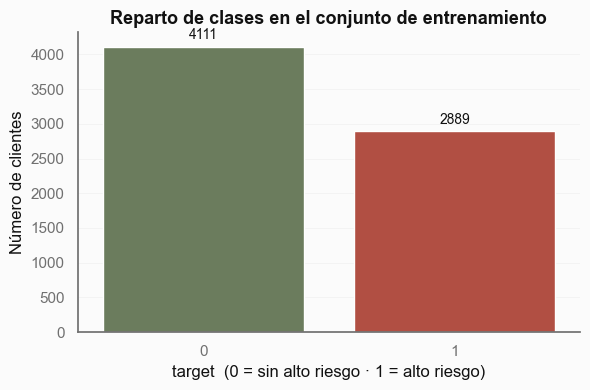

In [5]:
print("Distribución absoluta del target:")
print(df_train["target"].value_counts())

print("\nDistribución porcentual del target:")
print(
    df_train["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df_train,
    x="target",
    hue="target",
    palette=[POSITIVE, NEGATIVE],
    legend=False,
    ax=ax,
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d", padding=3, color=INK)

ax.set_title("Reparto de clases en el conjunto de entrenamiento", color=INK)
ax.set_xlabel("target  (0 = sin alto riesgo · 1 = alto riesgo)")
ax.set_ylabel("Número de clientes")

plt.tight_layout()
plt.show()

**Interpretación del reparto de clases**

El conjunto está **razonablemente equilibrado**: **41,3 %** de los clientes son de alto riesgo
(`target = 1`) frente a un **58,7 %** que no lo son. Dos consecuencias prácticas:

1. **No estamos ante un problema de clase rara.** No hacen falta técnicas de remuestreo (SMOTE,
   submuestreo) ni `class_weight="balanced"`; con 2.889 casos positivos hay material de sobra
   para aprender.
2. **La *accuracy* sigue siendo engañosa, aunque menos de lo habitual.** Un modelo que predijese
   "sin riesgo" para todo el mundo acertaría el **58,7 %**. Ese es el suelo real: cualquier
   accuracy por debajo de esa cifra es peor que no tener modelo. Por eso la métrica principal
   será el **ROC-AUC**, que mide la capacidad de *ordenar* clientes por riesgo con independencia
   del umbral que acabemos eligiendo.

---

## 3. Análisis exploratorio (EDA)

El EDA no es un trámite decorativo antes de modelar: aquí es donde se decide qué preprocesado
hace falta, qué variables prometen y —como se verá en el apartado 3.7— si la etiqueta significa
lo que el enunciado dice que significa.

### 3.1 Estadísticos descriptivos

`describe().T` transpone la tabla para que cada variable sea una fila. Buscamos tres cosas:
escalas muy distintas entre variables, valores imposibles (negativos donde no deberían serlo) y
colas largas que delaten asimetría.

In [6]:
df_train.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
edad,7000.0,40.67,11.64,18.0,32.00,40.00,49.00,75.0
antiguedad_cliente_meses,7000.0,54.51,33.64,2.0,29.75,47.00,73.00,180.0
ingresos_anuales,6916.0,37467.97,21500.55,12000.0,22243.25,32390.00,46740.25,180000.0
num_productos,7000.0,3.21,1.47,1.0,2.00,3.00,4.00,8.0
contactos_ultimos_90d,7000.0,2.54,1.58,0.0,1.00,2.00,3.00,10.0
incidencias_ultimos_90d,7000.0,0.79,0.89,0.0,0.00,1.00,1.00,6.0
dias_desde_ultimo_login,7000.0,36.37,25.66,0.0,17.00,31.00,49.00,180.0
sesiones_mes,7000.0,7.02,2.68,0.0,5.00,7.00,9.00,18.0
gasto_mensual,7000.0,112.02,97.34,5.0,50.06,83.42,139.48,800.0
descuento_pct,7000.0,12.27,7.55,0.0,6.50,12.00,17.40,40.0


**Lectura de los descriptivos**

- **Las escalas son radicalmente distintas.** `ingresos_anuales` va de 12.000 a 180.000 mientras
  `satisfaccion_1_10` se mueve entre 1 y 10. Un modelo lineal regularizado penalizaría
  injustamente a las variables de rango pequeño, así que **habrá que estandarizar**.
- **`nps` toma valores negativos**, y es correcto: el *Net Promoter Score* se define en el rango
  −100 a +100. No es un error de datos.
- **Varias variables están sesgadas a la derecha.** `ingresos_anuales` tiene mediana 32.390 y
  máximo 180.000; `gasto_mensual`, mediana 83 y máximo 800. Son colas largas típicas de
  variables monetarias, no valores corruptos.
- **`count` no es 7.000 en todas las filas**: cuatro variables tienen huecos. Los cuantificamos a
  continuación.

### 3.2 Valores ausentes

Un ausente puede tratarse de tres formas: eliminar la fila, eliminar la columna o imputar. La
decisión depende del **volumen** y de si el hueco es informativo o accidental.

In [7]:
ausentes = pd.DataFrame({
    "n_ausentes": df_train.isna().sum(),
    "pct_train": df_train.isna().mean().mul(100).round(2),
    "pct_test": df_test.isna().mean().mul(100).round(2),
})

ausentes[ausentes["n_ausentes"] > 0].sort_values("n_ausentes", ascending=False)

,n_ausentes,pct_train,pct_test
ingresos_anuales,84,1.2,1.2
meses_desde_ultimo_contacto,84,1.2,1.2
nps,84,1.2,1.2
uso_app_pct,84,1.2,1.2


**Lectura de los ausentes**

Solo **4 de las 24 variables** tienen huecos, y todas exactamente al **1,2 %** (84 filas de 7.000).
Dos detalles importantes:

- Ese 1,2 % idéntico en las cuatro variables y **replicado con la misma proporción en el `test`**
  apunta a una ausencia aleatoria introducida de forma controlada, no a un fallo de un sistema
  concreto que afectara a un perfil de cliente.
- Con un volumen tan bajo, **imputar es claramente mejor que eliminar filas**: descartar 84
  clientes por perder un dato de cuatro sería tirar 20 variables buenas para ahorrarse una.

Imputaremos con la **mediana** en las numéricas (robusta frente a las colas largas que acabamos
de ver; la media se desplazaría con los ingresos de 180.000) y con la **moda** en las categóricas.

### 3.3 Tipología de variables

Separamos numéricas de categóricas porque **cada grupo necesita un preprocesado distinto**: las
numéricas se imputan y escalan, las categóricas se imputan y codifican.

Nótese que excluimos `target` (es la etiqueta, no un predictor) y `id_cliente` (es un
identificador arbitrario: incluirlo permitiría al modelo "memorizar" clientes concretos sin
aprender nada generalizable).

In [8]:
X_temp = df_train.drop(columns=["target", "id_cliente"])

variables_numericas = (
    X_temp
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

variables_categoricas = (
    X_temp
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print(f"Variables numéricas ({len(variables_numericas)}):")
for v in variables_numericas:
    print("  -", v)

print(f"\nVariables categóricas ({len(variables_categoricas)}):")
for v in variables_categoricas:
    print("  -", v)

Variables numéricas (19):
  - edad
  - antiguedad_cliente_meses
  - ingresos_anuales
  - num_productos
  - contactos_ultimos_90d
  - incidencias_ultimos_90d
  - dias_desde_ultimo_login
  - sesiones_mes
  - gasto_mensual
  - descuento_pct
  - satisfaccion_1_10
  - nps
  - tickets_ultimos_90d
  - uso_app_pct
  - pagos_atrasados
  - meses_desde_ultimo_contacto
  - promociones_abiertas
  - emails_abiertos_pct
  - referidos

Variables categóricas (4):
  - zona
  - canal_preferido
  - tipo_cliente
  - plan


### 3.4 Distribución de las variables numéricas

Un histograma por variable. Lo que buscamos no es belleza estadística sino anomalías:
distribuciones bimodales, picos artificiales en un valor concreto o truncamientos.

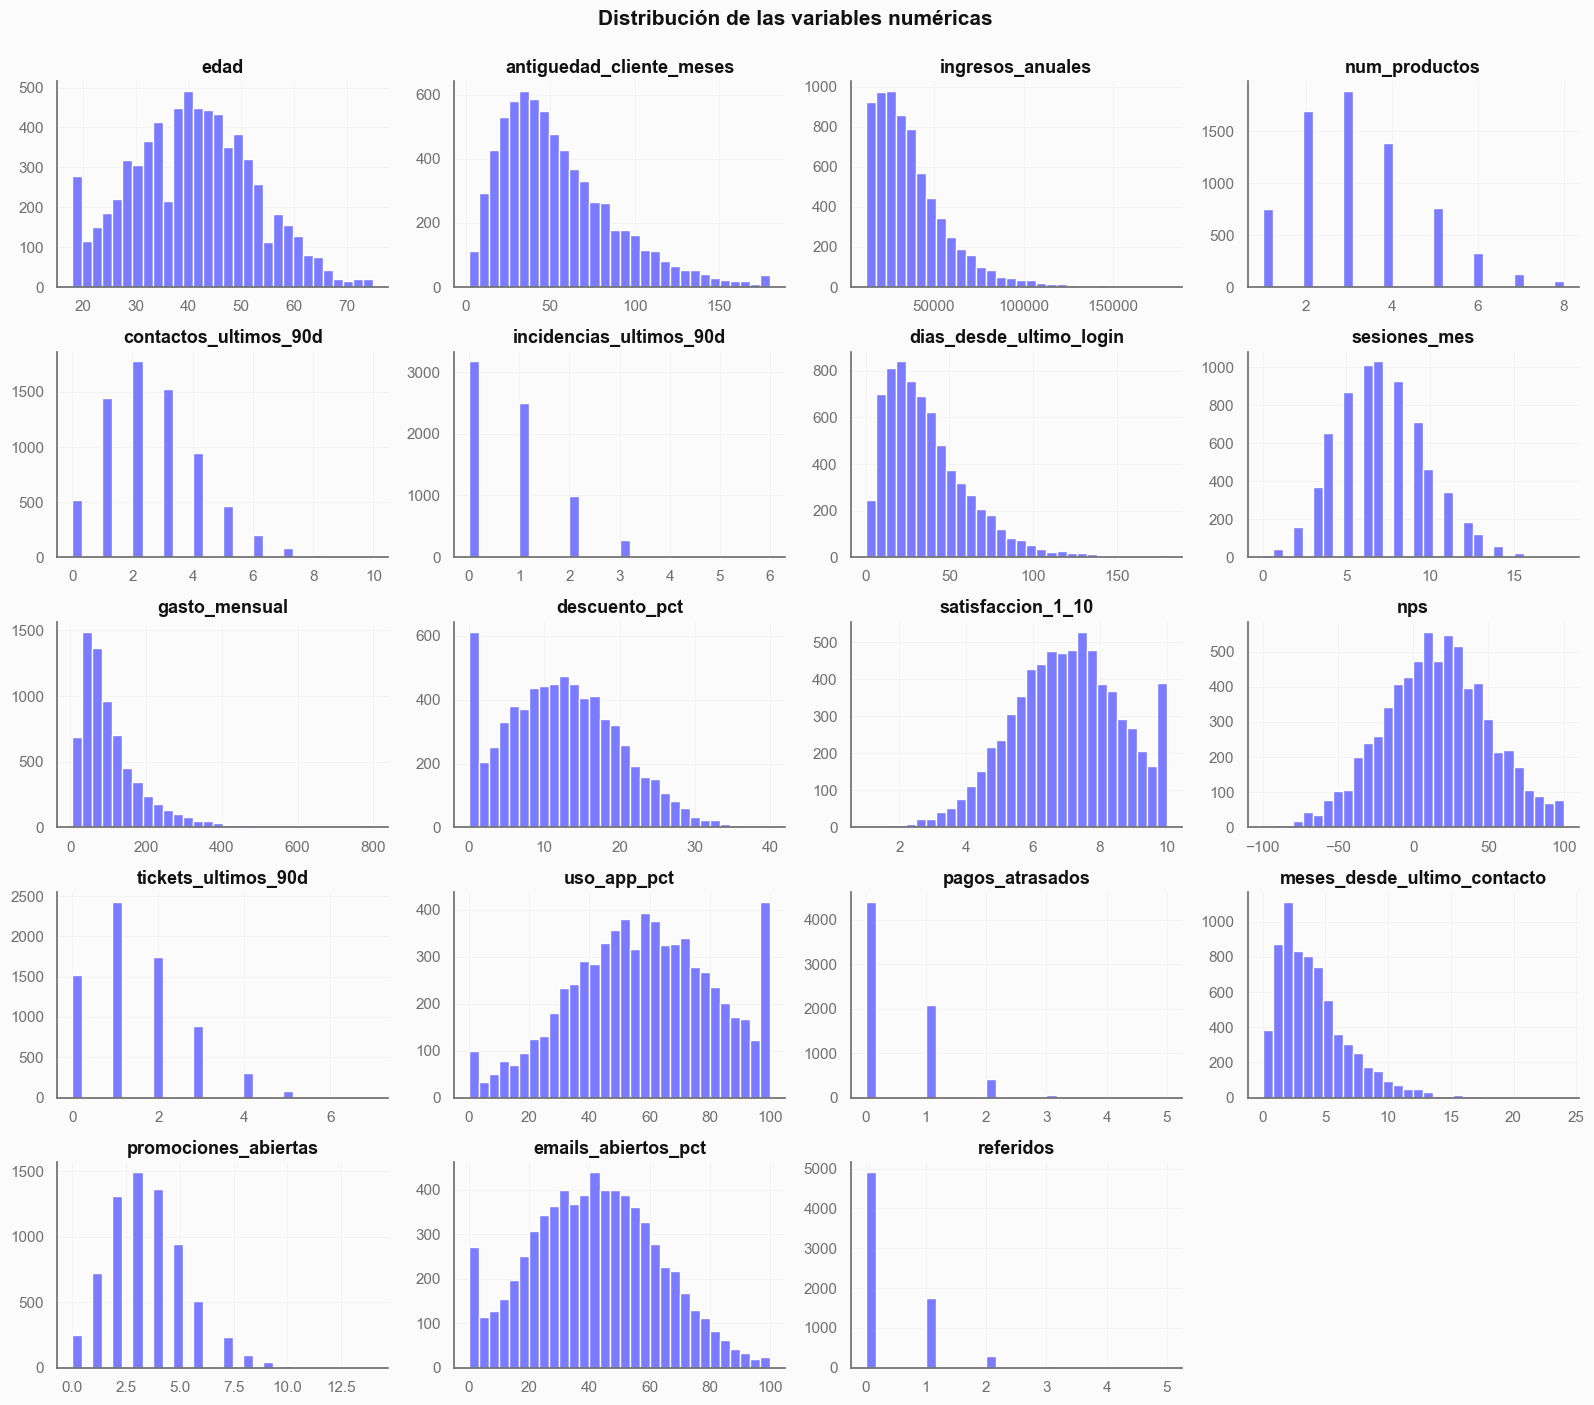

In [9]:
df_train[variables_numericas].hist(
    figsize=(16, 14),
    bins=30,
    color=PURPLE,
    edgecolor="white",
)

plt.suptitle(
    "Distribución de las variables numéricas",
    fontsize=15,
    fontweight="bold",
    color=INK,
    y=1.00,
)

plt.tight_layout()
plt.show()

**Lectura de las distribuciones**

- `edad`, `satisfaccion_1_10`, `nps`, `uso_app_pct` y `emails_abiertos_pct` son
  **aproximadamente simétricas**: se comportan como variables continuas bien formadas.
- `ingresos_anuales`, `gasto_mensual` y `dias_desde_ultimo_login` presentan la **asimetría a la
  derecha** que ya anticipaban los descriptivos.
- `pagos_atrasados`, `referidos`, `incidencias_ultimos_90d` y `tickets_ultimos_90d` son
  **conteos concentrados en cero**. Es lo esperable: la mayoría de clientes nunca ha tenido una
  incidencia.
- No aparece ningún pico artificial ni valores centinela del tipo `-999`. Los datos están limpios.

### 3.5 Matriz de correlaciones

Dos preguntas distintas en un mismo gráfico:

1. **Última fila/columna (`target`):** ¿qué variables tienen relación lineal con el riesgo?
2. **Resto de la matriz:** ¿hay variables muy correlacionadas entre sí? La **multicolinealidad**
   no daña la capacidad predictiva de una regresión logística, pero sí desestabiliza sus
   coeficientes y hace su interpretación poco fiable.

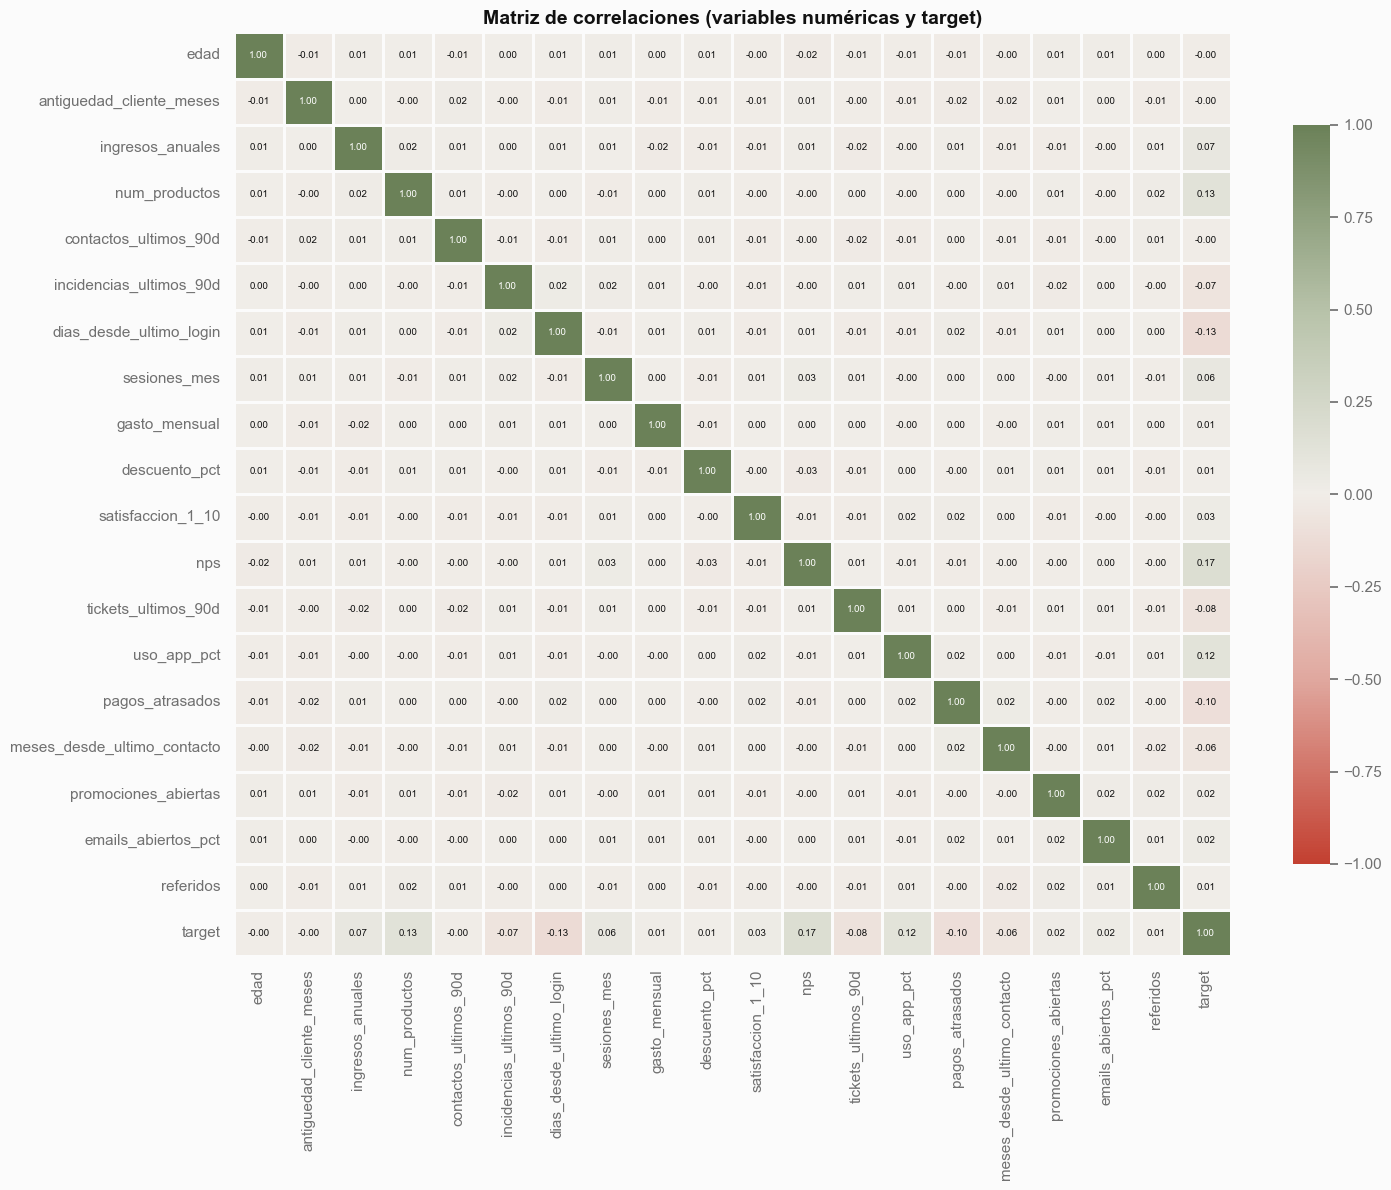

In [10]:
corr = df_train[variables_numericas + ["target"]].corr()

plt.figure(figsize=(15, 12))

ax = sns.heatmap(
    corr,
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.8},
)
color_annotations(ax, corr.values, threshold=0.8)

plt.title("Matriz de correlaciones (variables numéricas y target)", fontsize=14, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

In [11]:
corr_target = (
    corr["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
    .to_frame("correlacion_con_target")
    .round(4)
)

corr_target

,correlacion_con_target
nps,0.1737
dias_desde_ultimo_login,-0.1295
num_productos,0.1260
uso_app_pct,0.1211
pagos_atrasados,-0.1049
tickets_ultimos_90d,-0.0839
incidencias_ultimos_90d,-0.0697
ingresos_anuales,0.0691
sesiones_mes,0.0641
meses_desde_ultimo_contacto,-0.0574


**Lectura de las correlaciones**

- **Ninguna variable supera |0,18| de correlación con el target.** La más fuerte es `nps`
  (**+0,174**), seguida de `dias_desde_ultimo_login` (**−0,130**), `num_productos` (**+0,126**),
  `uso_app_pct` (**+0,121**) y `pagos_atrasados` (**−0,105**). Esto marca la expectativa realista
  del proyecto: **no vamos a construir un modelo muy preciso**, porque la señal disponible es
  débil. Un AUC de 0,95 sería aquí una señal de alarma, no de éxito.
- **No hay multicolinealidad preocupante** entre predictores: fuera de la diagonal ningún par se
  acerca a 0,8. Podremos interpretar los coeficientes sin reservas.
- **Y hay algo que no cuadra con el enunciado.** `pagos_atrasados` correlaciona **negativamente**
  con el riesgo de impago, y `nps` (satisfacción) lo hace **positivamente**. Es exactamente al
  revés de lo que dicta el sentido común del negocio. Lo investigamos en el apartado 3.7.

### 3.6 Variables numéricas frente al target

La correlación de Pearson solo captura relaciones lineales. Los diagramas de caja permiten ver
la separación real entre ambos grupos: si las dos cajas de una variable se solapan casi por
completo, esa variable aporta poco por sí sola.

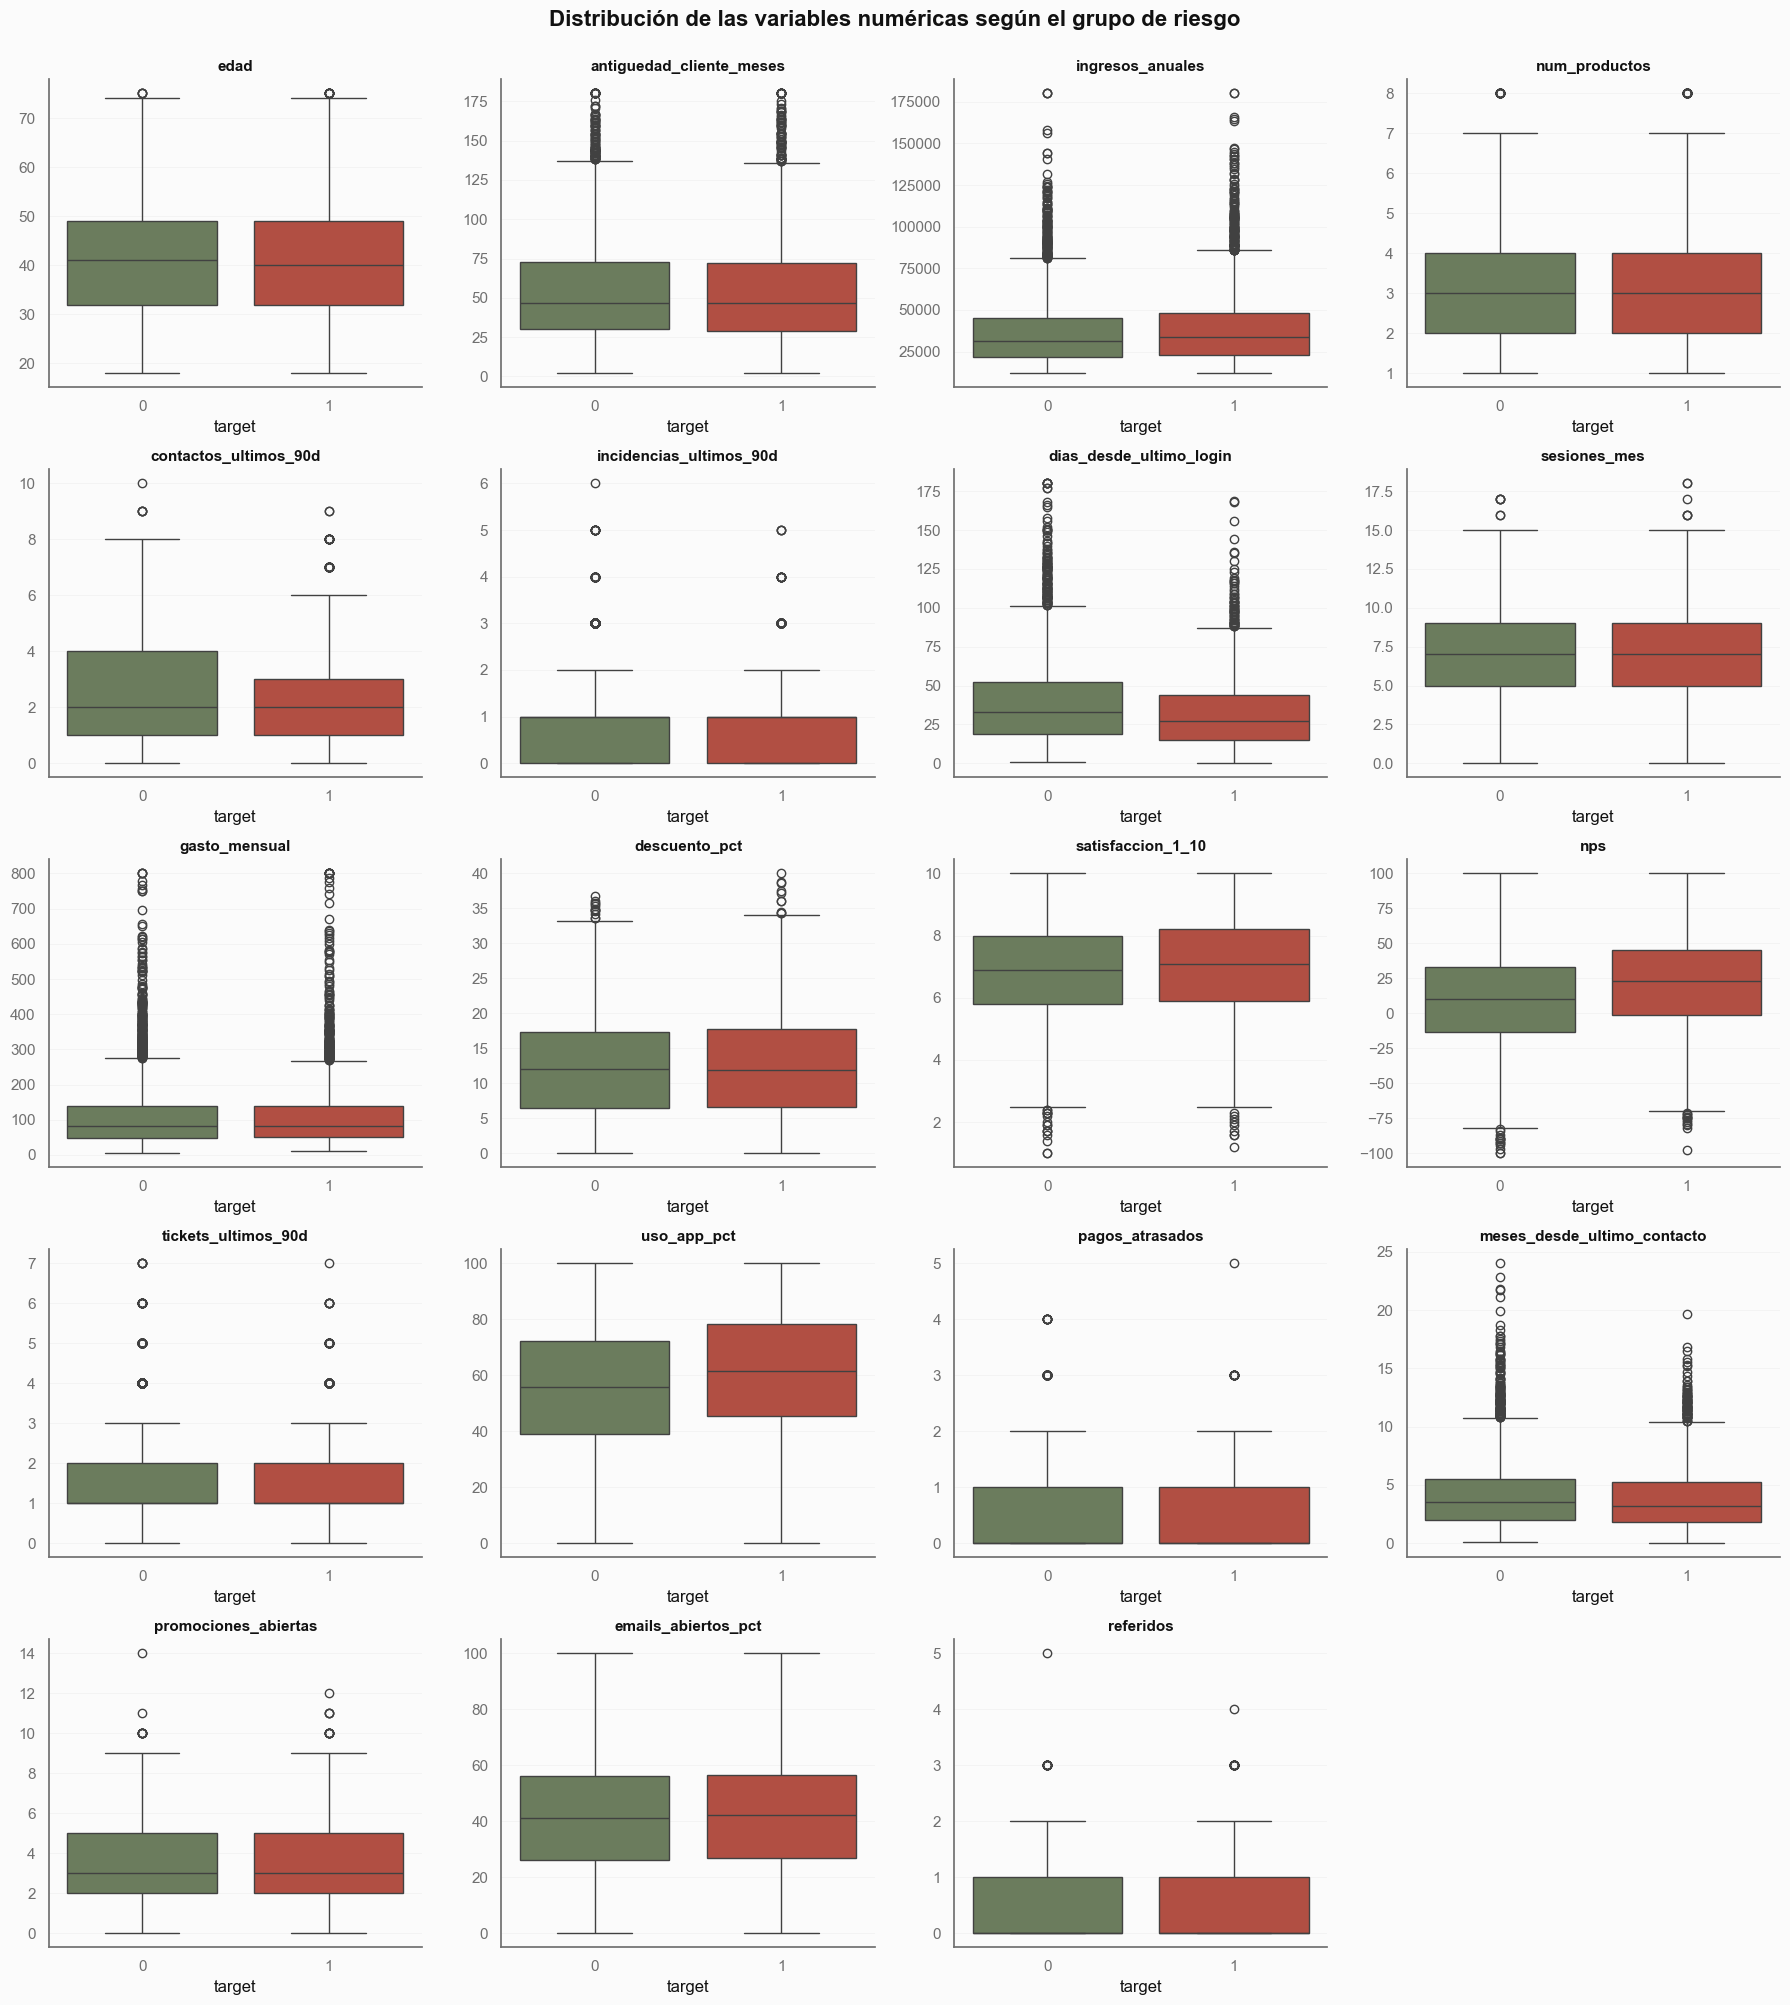

In [12]:
n_vars = len(variables_numericas)
n_cols = 4
n_filas = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    nrows=n_filas,
    ncols=n_cols,
    figsize=(18, 4 * n_filas),
)

axes = axes.flatten()

for i, variable in enumerate(variables_numericas):

    sns.boxplot(
        data=df_train,
        x="target",
        y=variable,
        hue="target",
        palette=[POSITIVE, NEGATIVE],
        legend=False,
        ax=axes[i],
    )

    axes[i].set_title(f"{variable}", fontsize=11, color=INK)
    axes[i].set_xlabel("target")
    axes[i].set_ylabel("")

# Eliminamos los ejes sobrantes de la última fila
for j in range(n_vars, len(axes)):
    axes[j].remove()

fig.suptitle(
    "Distribución de las variables numéricas según el grupo de riesgo",
    fontsize=16,
    fontweight="bold",
    color=INK,
    y=1.00,
)

plt.tight_layout()
plt.show()

**Lectura de los diagramas de caja**

La imagen confirma lo que anticipaban las correlaciones: **en casi todas las variables las dos
cajas se solapan de forma masiva**. Las medianas se desplazan ligeramente en `nps`,
`dias_desde_ultimo_login`, `num_productos` y `uso_app_pct`, pero no hay ni una sola variable que
separe los grupos con claridad.

Esto es una información valiosa, no un fracaso: nos dice que **ninguna regla de negocio simple
del tipo "si X > k, cliente de riesgo" va a funcionar**. Si un modelo multivariante aporta valor
aquí, será combinando muchas señales débiles, no encontrando una fuerte.

### 3.7 La paradoja del signo: ¿qué mide realmente `target`?

Las correlaciones dejaron una anomalía pendiente. Antes de modelar hay que resolverla, porque
condiciona por completo cómo se puede usar el resultado. Comparamos las medias de cada variable
en ambos grupos.

In [13]:
comparacion = (
    df_train
    .groupby("target")[variables_numericas]
    .mean()
    .T
)

comparacion.columns = ["target_0", "target_1"]

comparacion["dif_pct"] = (
    (comparacion["target_1"] - comparacion["target_0"])
    / comparacion["target_0"].abs()
    * 100
).round(1)

comparacion.sort_values("dif_pct", key=abs, ascending=False).round(2)

,target_0,target_1,dif_pct
nps,9.80,22.17,126.3
pagos_atrasados,0.51,0.37,-27.7
dias_desde_ultimo_login,39.15,32.41,-17.2
incidencias_ultimos_90d,0.84,0.72,-14.9
tickets_ultimos_90d,1.57,1.37,-13.0
num_productos,3.05,3.43,12.4
uso_app_pct,55.31,61.12,10.5
ingresos_anuales,36221.59,39238.74,8.3
meses_desde_ultimo_contacto,4.20,3.86,-8.0
sesiones_mes,6.88,7.23,5.1


El contraste de medias no basta: una diferencia puede venir de unos pocos valores extremos.
Comprobamos si la relación es **monótona**, es decir, si la tasa de riesgo cae de forma sostenida
a medida que aumenta el número de pagos atrasados.

In [14]:
for variable in ["pagos_atrasados", "incidencias_ultimos_90d", "tickets_ultimos_90d"]:

    tabla = (
        df_train
        .groupby(variable)["target"]
        .agg(tasa_riesgo="mean", n_clientes="size")
    )

    tabla["tasa_riesgo"] = (tabla["tasa_riesgo"] * 100).round(1)

    # Nos quedamos con los tramos con masa suficiente para ser fiables
    tabla = tabla[tabla["n_clientes"] >= 20]

    print(f"--- Tasa de target=1 (%) según {variable} ---")
    print(tabla.to_string())
    print()

--- Tasa de target=1 (%) según pagos_atrasados ---
                 tasa_riesgo  n_clientes
pagos_atrasados                         
0                       44.4        4406
1                       38.8        2089
2                       25.0         428
3                       22.4          67

--- Tasa de target=1 (%) según incidencias_ultimos_90d ---
                         tasa_riesgo  n_clientes
incidencias_ultimos_90d                         
0                               44.1        3173
1                               40.9        2506
2                               36.6         992
3                               32.7         275
4                               25.0          40

--- Tasa de target=1 (%) según tickets_ultimos_90d ---
                     tasa_riesgo  n_clientes
tickets_ultimos_90d                         
0                           46.2        1522
1                           43.0        2429
2                           39.9        1745
3                  

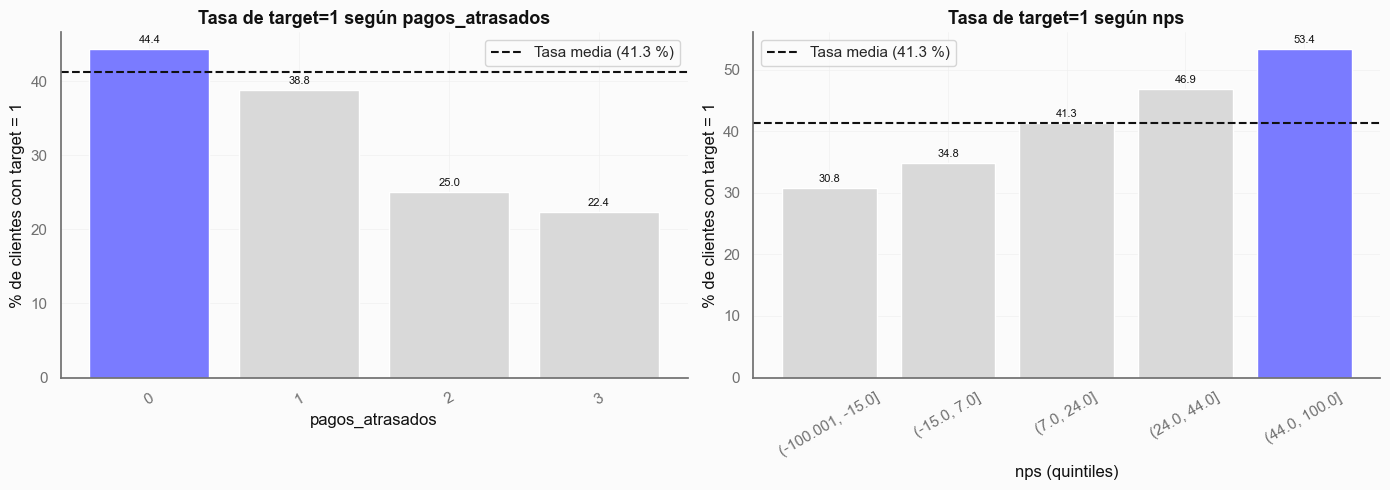

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tasa_media_global = df_train["target"].mean() * 100

for ax, variable in zip(axes, ["pagos_atrasados", "nps"]):

    if variable == "nps":
        grupos = pd.qcut(df_train[variable], 5)
        etiqueta_x = "nps (quintiles)"
    else:
        grupos = df_train[variable]
        etiqueta_x = variable

    tasa = (
        df_train
        .groupby(grupos, observed=True)["target"]
        .agg(tasa="mean", n="size")
    )

    tasa = tasa[tasa["n"] >= 20]

    valores = tasa["tasa"] * 100
    top_idx = valores.values.argmax()
    colores = [PURPLE if i == top_idx else NEUTRAL_BAR for i in range(len(valores))]

    barras = ax.bar(
        tasa.index.astype(str),
        valores,
        color=colores,
    )
    ax.bar_label(barras, fmt="%.1f", padding=3, color=INK, fontsize=8)

    ax.axhline(
        tasa_media_global,
        color=INK,
        linestyle="--",
        label=f"Tasa media ({tasa_media_global:.1f} %)",
    )

    ax.set_title(f"Tasa de target=1 según {variable}", color=INK)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel("% de clientes con target = 1")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.tight_layout()
plt.show()

**El hallazgo: la etiqueta no se comporta como su nombre**

> Los clientes marcados como `target = 1` pagan **mejor**, se quejan **menos** y están **más
> satisfechos** que los marcados como `target = 0`. La relación es limpia y monótona, no un
> artefacto de unos pocos casos extremos.

Los números concretos:

| `target = 1` frente a `target = 0` | Dirección | Lectura de negocio |
|---|---|---|
| `pagos_atrasados` **−27,7 %** | Menos impagos previos | Con **0** pagos atrasados el **44,4 %** es `target=1`; con **3**, solo el **22,4 %** |
| `nps` **+126 %** (9,8 → 22,2) | Más satisfecho | Del quintil inferior de NPS (**30,8 %**) al superior (**53,4 %**) |
| `tickets_ultimos_90d` **−13,0 %** | Menos reclamaciones | Cae del **46,2 %** (0 tickets) al **16,7 %** (7 tickets) |
| `incidencias_ultimos_90d` **−14,9 %** | Menos incidencias | Misma pendiente descendente |
| `ingresos_anuales` **+8,3 %** | Mayor renta | Contrario al riesgo crediticio esperado |
| `num_productos` **+12,4 %** | Más vinculado | Del **30,8 %** (1 producto) al **67,7 %** (7 productos) |

**Qué significa esto.** El perfil que el modelo va a aprender a detectar es el de un cliente
**vinculado, activo, satisfecho y solvente** — justo lo contrario de un moroso. Caben dos
explicaciones: que la etiqueta esté **invertida** respecto a su nombre, o que `target` codifique
en realidad otro fenómeno (propensión a contratar, pertenencia a un segmento premium) y la
etiqueta "impago" sea únicamente el envoltorio narrativo del ejercicio.

**Qué hacemos al respecto.** No tocamos nada. El objetivo es predecir `target` tal y como viene
definido, y eso es lo que haremos: técnicamente el problema es idéntico y las métricas son igual
de válidas. Pero lo dejamos escrito de forma explícita porque tiene una consecuencia operativa
de primer orden:

> **Los coeficientes de este modelo no deben leerse como reglas de política de crédito.** Un
> comité de riesgos que interpretase literalmente la salida concluiría que hay que exigir más
> garantías a los clientes que nunca se han retrasado en un pago. Antes de llevar este modelo a
> producción, el negocio tiene que confirmar la definición exacta de `target` en el sistema de
> origen.

Este es el tipo de comprobación que separa un ejercicio de modelado de un análisis utilizable:
el modelo funcionará igual de bien en ambos casos, pero **la recomendación de negocio se
invierte por completo** según cuál sea la respuesta.

### 3.8 Variables categóricas

Cerramos el EDA con las cuatro variables categóricas. Comparamos la tasa de riesgo de cada
categoría con la tasa media global (**41,3 %**): si todas las categorías de una variable se pegan
a esa línea, esa variable no discrimina.

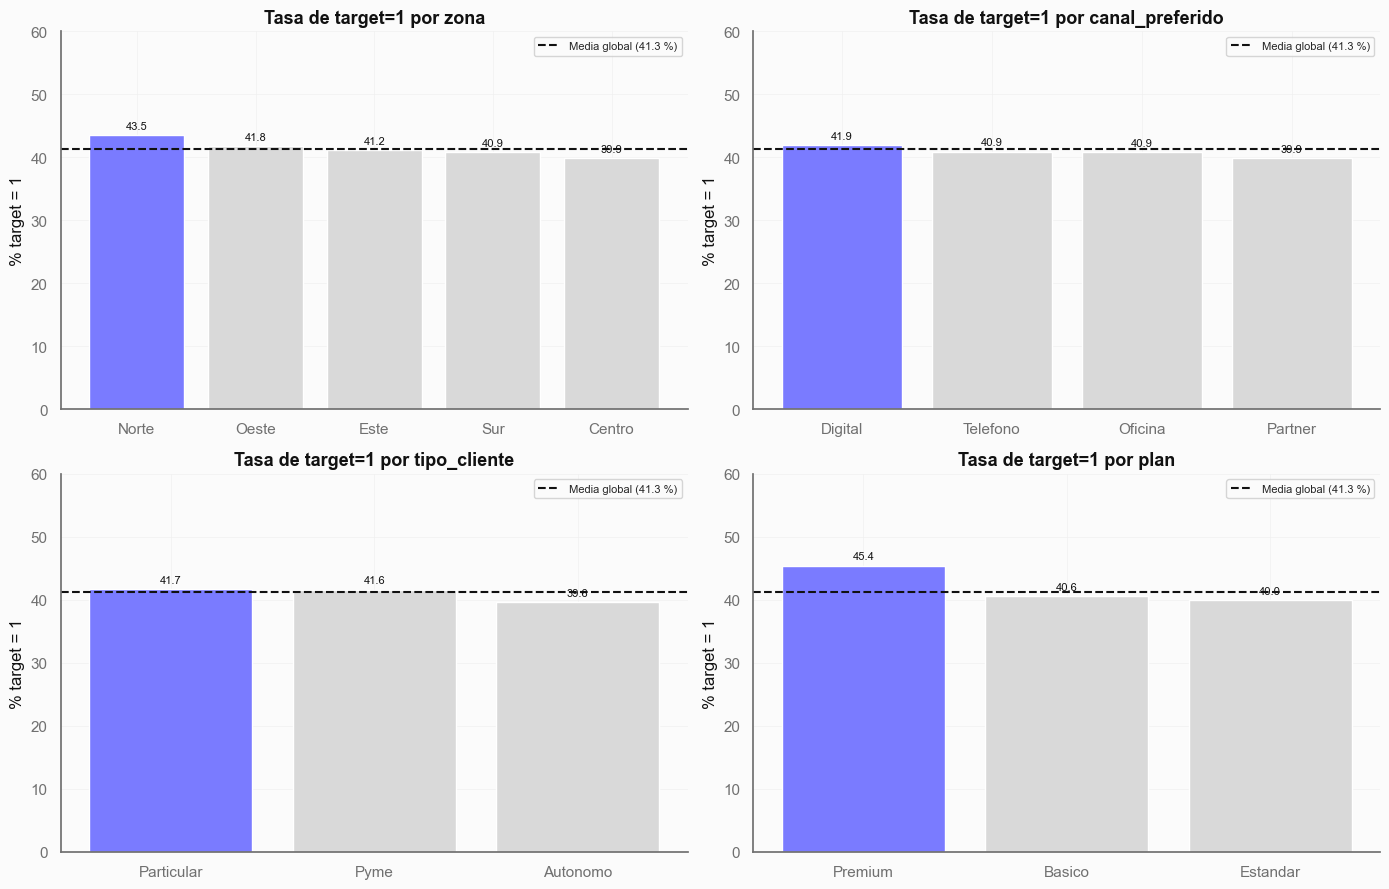

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, variable in zip(axes, variables_categoricas):

    tasa = (
        df_train
        .groupby(variable)["target"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    top_idx = tasa.values.argmax()
    colores = [PURPLE if i == top_idx else NEUTRAL_BAR for i in range(len(tasa))]

    barras = ax.bar(tasa.index.astype(str), tasa.values, color=colores)
    ax.bar_label(barras, fmt="%.1f", padding=3, color=INK, fontsize=8)

    ax.axhline(
        tasa_media_global,
        color=INK,
        linestyle="--",
        label=f"Media global ({tasa_media_global:.1f} %)",
    )

    ax.set_title(f"Tasa de target=1 por {variable}", color=INK)
    ax.set_xlabel("")
    ax.set_ylabel("% target = 1")
    ax.set_ylim(0, 60)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
for variable in variables_categoricas:

    resumen = pd.DataFrame({
        "n_clientes": df_train[variable].value_counts(),
        "tasa_riesgo_pct": (
            df_train.groupby(variable)["target"].mean().mul(100).round(1)
        ),
    })

    print(f"--- {variable} ---")
    print(resumen.to_string())
    print()

--- zona ---
        n_clientes  tasa_riesgo_pct
zona                               
Centro        1943             39.9
Este          1280             41.2
Norte         1246             43.5
Oeste         1087             41.8
Sur           1444             40.9

--- canal_preferido ---
                 n_clientes  tasa_riesgo_pct
canal_preferido                             
Digital                3385             41.9
Oficina                1382             40.9
Partner                 730             39.9
Telefono               1503             40.9

--- tipo_cliente ---
              n_clientes  tasa_riesgo_pct
tipo_cliente                             
Autonomo            1443             39.6
Particular          4798             41.7
Pyme                 759             41.6

--- plan ---
          n_clientes  tasa_riesgo_pct
plan                                 
Basico          2447             40.6
Estandar        3197             40.0
Premium         1356             45.4



**Lectura de las categóricas**

Las cuatro variables son **prácticamente planas**. El recorrido completo entre la categoría con
más riesgo y la que menos es de apenas unos puntos porcentuales:

| Variable | Rango de tasa de riesgo | Amplitud |
|---|---|---|
| `plan` | 40,0 % (Estándar) → 45,4 % (Premium) | 5,4 pp |
| `zona` | 39,9 % (Centro) → 43,5 % (Norte) | 3,6 pp |
| `canal_preferido` | 39,9 % (Partner) → 41,9 % (Digital) | 2,0 pp |
| `tipo_cliente` | 39,6 % (Autónomo) → 41,7 % (Particular) | 2,1 pp |

Con la excepción marginal de `plan`, **ninguna aporta señal relevante**. Las mantenemos en el
modelo —no estorban y su coste computacional es nulo— pero ya sabemos que el poder predictivo
tendrá que salir de las numéricas. Lo verificaremos cuantitativamente en el apartado 9.

---

## 4. Preparación de los datos

### 4.1 Separación de predictores y etiqueta

Convención estándar: `X` son las variables de entrada, `y` es lo que queremos predecir. Se
excluyen las mismas dos columnas que en el apartado 3.3, y por los mismos motivos: `target`
porque es la respuesta e `id_cliente` porque es un identificador sin contenido predictivo.

In [18]:
X = df_train.drop(columns=["target", "id_cliente"])
y = df_train["target"]

print("X:", X.shape)
print("y:", y.shape)

X: (7000, 23)
y: (7000,)


### 4.2 Partición en entrenamiento y validación

Reservamos un **20 %** de los datos que el modelo no verá durante el entrenamiento. Ese conjunto
de validación es nuestra única estimación honesta de cómo se comportará con clientes nuevos.

El parámetro clave es **`stratify=y`**: obliga a que la proporción de clases sea la misma en
ambas particiones. Sin él, el azar podría dejar un 45 % de positivos en train y un 37 % en
validación, y las métricas serían difíciles de comparar. Con solo 7.000 filas ese riesgo es real,
no teórico.

In [19]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {X_train.shape[0]:,} clientes")
print(f"Validación:    {X_valid.shape[0]:,} clientes")

print("\nProporción de target=1")
print(f"  Entrenamiento: {y_train.mean():.4f}")
print(f"  Validación:    {y_valid.mean():.4f}")

Entrenamiento: 5,600 clientes
Validación:    1,400 clientes

Proporción de target=1
  Entrenamiento: 0.4127
  Validación:    0.4129


**Comprobación:** ambas particiones tienen una proporción de positivos prácticamente idéntica
(**41,3 %**). La estratificación ha funcionado.

### 4.3 Pipeline de preprocesado

Aquí está la pieza más importante del notebook desde el punto de vista metodológico. En lugar de
transformar el DataFrame a mano, encapsulamos todo el preprocesado en un objeto `Pipeline` que
se encadenará con el modelo.

**Por qué un `Pipeline` y no transformaciones sueltas.** Si imputásemos la mediana sobre el
DataFrame completo *antes* de partir en train/validación, esa mediana se habría calculado usando
también las filas de validación. Es una **fuga de información sutil pero real**: el modelo
recibiría, indirectamente, información de datos que se supone que no ha visto. Con un `Pipeline`,
`.fit()` aprende la mediana **solo con el train** y `.transform()` la aplica tal cual a
validación y test. La fuga es imposible por construcción.

Además, el mismo objeto se aplicará al `test` final sin riesgo de olvidar un paso o aplicarlos en
distinto orden.

**Rama numérica** (2 pasos):

| Paso | Qué hace | Por qué |
|---|---|---|
| `SimpleImputer(strategy="median")` | Rellena los huecos con la mediana | Robusta frente a las colas largas del apartado 3.1; la media se desplazaría con los ingresos de 180.000 € |
| `StandardScaler()` | Deja cada variable con media 0 y desviación 1 | La regresión logística usa regularización L2 por defecto, que penaliza los coeficientes grandes: sin escalar, castigaría a `satisfaccion_1_10` (rango 1-10) mucho más que a `ingresos_anuales` |

In [20]:
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

**Rama categórica** (2 pasos):

| Paso | Qué hace | Por qué |
|---|---|---|
| `SimpleImputer(strategy="most_frequent")` | Rellena con la categoría más frecuente | La mediana no está definida para texto |
| `OneHotEncoder(handle_unknown="ignore")` | Convierte cada categoría en una columna binaria | Un modelo no puede operar con texto. `handle_unknown="ignore"` es la clave: si en el `test` apareciera una zona que no existe en el train, en lugar de romperse la codifica como todo ceros |

Usamos *one-hot* y no una codificación ordinal porque estas categorías **no tienen orden natural**:
asignar Norte=0, Sur=1, Este=2 le diría al modelo que "Este es el doble que Sur", lo cual no
significa nada.

In [21]:
transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

El `ColumnTransformer` aplica cada rama a su bloque de columnas y concatena los resultados en
una única matriz lista para el modelo.

In [22]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas),
    ]
)

preprocesador

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


---

## 5. Modelo baseline: regresión logística

Empezamos por el modelo más simple que puede resolver el problema. Un **baseline** no es un
modelo de descarte: es la vara de medir. Cualquier alternativa más compleja que probemos después
tendrá que demostrar que supera este número; si no lo hace, la complejidad no está justificada.

La regresión logística es la elección natural aquí por tres razones:

1. **Es interpretable.** Cada variable tiene un coeficiente que se traduce en un *odds ratio*, y
   en un contexto de riesgo esa trazabilidad suele ser un requisito regulatorio, no un lujo.
2. **Devuelve probabilidades calibradas**, no solo etiquetas. Es exactamente lo que pide el
   entregable (`prob_target_1`).
3. **Con señal débil y relaciones aparentemente lineales**, un modelo de baja varianza es la
   apuesta correcta: hay poco que sobreajustar y mucho ruido que evitar.

`max_iter=2000` sube el límite de iteraciones del optimizador respecto al valor por defecto (100),
que con 33 columnas resultantes del one-hot no siempre basta para converger.

In [23]:
modelo_logistico = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

pipeline_logistico = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", modelo_logistico),
    ]
)

pipeline_logistico

,steps,"[('preprocesador', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Al llamar a `.fit()`, el pipeline ejecuta la secuencia completa en un solo paso: aprende las
medianas y las modas del train, aprende las escalas, aprende las categorías presentes y, con la
matriz resultante, ajusta los coeficientes de la regresión.

In [24]:
pipeline_logistico.fit(X_train, y_train)

print("Modelo entrenado.")
print("Columnas tras el preprocesado:",
      pipeline_logistico.named_steps["preprocesador"].get_feature_names_out().shape[0])

Modelo entrenado.
Columnas tras el preprocesado: 34


### 5.1 Predicciones sobre validación

Dos salidas distintas que conviene no confundir:

- **`predict_proba()`** devuelve la probabilidad estimada de cada clase. Nos quedamos con la
  columna `[:, 1]`, la probabilidad de `target = 1`. **Esta es la salida realmente valiosa**: es
  continua y permite ordenar clientes por riesgo.
- **`predict()`** devuelve directamente 0 o 1. Es un atajo que aplica internamente un umbral fijo
  de **0,5**. Ese 0,5 es una convención arbitraria de scikit-learn, **no una decisión de negocio**
  — lo cuestionaremos a fondo en el apartado 10.

In [25]:
y_prob = pipeline_logistico.predict_proba(X_valid)[:, 1]
y_pred = pipeline_logistico.predict(X_valid)

comparativa = pd.DataFrame({
    "target_real": y_valid.values,
    "prob_target_1": y_prob.round(4),
    "prediccion_umbral_05": y_pred,
})

comparativa.head(15)

,target_real,prob_target_1,prediccion_umbral_05
0,1,0.4863,0
1,1,0.3203,0
2,0,0.4376,0
3,1,0.6241,1
4,1,0.7417,1
5,1,0.5614,1
6,0,0.2880,0
7,0,0.3158,0
8,1,0.5460,1
9,1,0.6257,1


In [26]:
print(f"Probabilidad mínima:  {y_prob.min():.4f}")
print(f"Probabilidad máxima:  {y_prob.max():.4f}")
print(f"Probabilidad media:   {y_prob.mean():.4f}")
print(f"Tasa real de target=1: {y_valid.mean():.4f}")

Probabilidad mínima:  0.0236
Probabilidad máxima:  0.8540
Probabilidad media:   0.4139
Tasa real de target=1: 0.4129


**Lectura de las probabilidades**

El modelo reparte probabilidades entre **0,02 y 0,85**: nunca llega a estar totalmente seguro en
ningún sentido, lo cual es coherente con la señal débil que vimos en el EDA.

Un detalle que sí es buena noticia: la **probabilidad media predicha (0,414)** coincide casi
exactamente con la **tasa real de positivos (0,413)**. El modelo está **bien calibrado en
promedio** — no infla ni desinfla el riesgo global de la cartera, que es justo lo que se le pide
a un *scoring*.

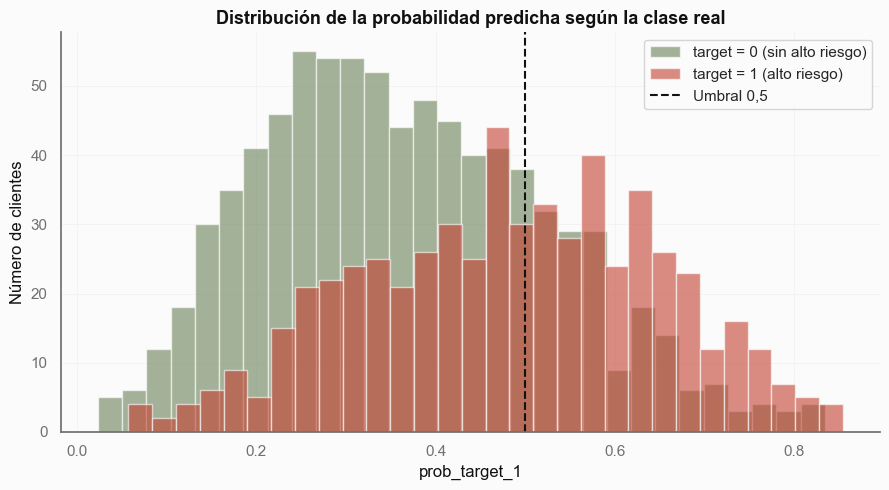

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for clase, color, etiqueta in [
    (0, POSITIVE, "target = 0 (sin alto riesgo)"),
    (1, NEGATIVE, "target = 1 (alto riesgo)"),
]:
    ax.hist(
        y_prob[y_valid.values == clase],
        bins=30,
        alpha=0.6,
        color=color,
        label=etiqueta,
    )

ax.axvline(0.5, color=INK, linestyle="--", label="Umbral 0,5")

ax.set_title("Distribución de la probabilidad predicha según la clase real", color=INK)
ax.set_xlabel("prob_target_1")
ax.set_ylabel("Número de clientes")
ax.legend()

plt.tight_layout()
plt.show()

**Lectura del gráfico de separación**

Este gráfico resume el proyecto entero mejor que cualquier métrica. Las dos distribuciones
**están desplazadas en la dirección correcta** —los clientes de riesgo real (rojo) se acumulan a
la derecha— pero **se solapan en la mayor parte del recorrido**.

Es la imagen visual de un modelo con señal real pero moderada: sirve para **ordenar y priorizar**
una cartera, no para tomar decisiones automáticas cliente a cliente.

---

## 6. Evaluación del baseline

Evaluamos en dos planos que responden a preguntas distintas:

- **Métricas independientes del umbral** (ROC-AUC, Log Loss, Average Precision): miden la calidad
  del *ranking* y de las probabilidades. Son las que sirven para comparar modelos entre sí.
- **Métricas dependientes del umbral** (accuracy, precisión, recall, F1): miden la calidad de la
  decisión final. Cambian por completo según dónde pongamos el corte.

### 6.1 ROC-AUC y Log Loss

**ROC-AUC** responde a: *si tomo un cliente de riesgo y uno sano al azar, ¿con qué probabilidad
el modelo asigna más riesgo al primero?* 0,5 es azar puro; 1,0 es separación perfecta. Es la
métrica principal del ejercicio porque **no depende del umbral**.

**Log Loss** penaliza las probabilidades mal calibradas: castiga con dureza estar muy seguro y
equivocarse. Complementa al AUC, que solo mira el orden y no la magnitud.

In [28]:
auc_valid = roc_auc_score(y_valid, y_prob)
logloss_valid = log_loss(y_valid, y_prob)
ap_valid = average_precision_score(y_valid, y_prob)

print(f"ROC-AUC:            {auc_valid:.4f}")
print(f"Log Loss:           {logloss_valid:.4f}")
print(f"Average Precision:  {ap_valid:.4f}   (baseline aleatorio: {y_valid.mean():.4f})")

ROC-AUC:            0.6985
Log Loss:           0.6196
Average Precision:  0.6055   (baseline aleatorio: 0.4129)


**Interpretación de las métricas globales**

- **ROC-AUC = 0,6985.** Ante dos clientes al azar, uno de riesgo y otro sano, el modelo ordena
  correctamente al de riesgo por delante **7 de cada 10 veces**. Es una capacidad
  **modesta pero claramente por encima del azar** (0,5). En la escala habitual de scoring de
  riesgo, un AUC de 0,70 se considera *aceptable*; los modelos de crédito en producción suelen
  moverse entre 0,75 y 0,85.
- **Log Loss = 0,6196.** Como referencia, un modelo que predijese siempre la tasa base (0,413)
  obtendría un Log Loss de ≈0,678. Nuestro modelo mejora esa cifra, confirmando que las
  probabilidades aportan información real.
- **Average Precision = 0,6055 frente a un baseline de 0,4129.** Entre los clientes que el modelo
  señala como más arriesgados, la concentración de positivos reales es **1,47 veces** la que
  saldría eligiendo al azar. Traducido a operativa: **priorizar por este score rinde un 47 % más
  que llamar a los clientes en orden alfabético**.

### 6.2 Métricas de clasificación con umbral 0,5

Ahora pasamos al plano de la decisión. Las cuatro métricas clásicas y qué significa cada una en
este caso concreto:

| Métrica | Pregunta que responde | Coste de equivocarse |
|---|---|---|
| **Accuracy** | ¿Qué porcentaje del total acierto? | Engañosa: el 58,7 % se consigue sin modelo |
| **Precisión** | De los que marco como riesgo, ¿cuántos lo son? | Precisión baja = molestar a clientes sanos |
| **Recall** | De los que son riesgo, ¿a cuántos detecto? | Recall bajo = impagos que se escapan |
| **F1** | Media armónica de las dos anteriores | Métrica de compromiso cuando ambos errores importan |

In [29]:
metricas_05 = {
    "Accuracy": accuracy_score(y_valid, y_pred),
    "Precisión": precision_score(y_valid, y_pred),
    "Recall": recall_score(y_valid, y_pred),
    "F1": f1_score(y_valid, y_pred),
}

for nombre, valor in metricas_05.items():
    print(f"{nombre:<12}: {valor:.4f}")

print(f"\n{'Tasa base':<12}: {1 - y_valid.mean():.4f}   (accuracy del modelo trivial 'todo 0')")

Accuracy    : 0.6664
Precisión   : 0.6259
Recall      : 0.4775
F1          : 0.5417

Tasa base   : 0.5871   (accuracy del modelo trivial 'todo 0')


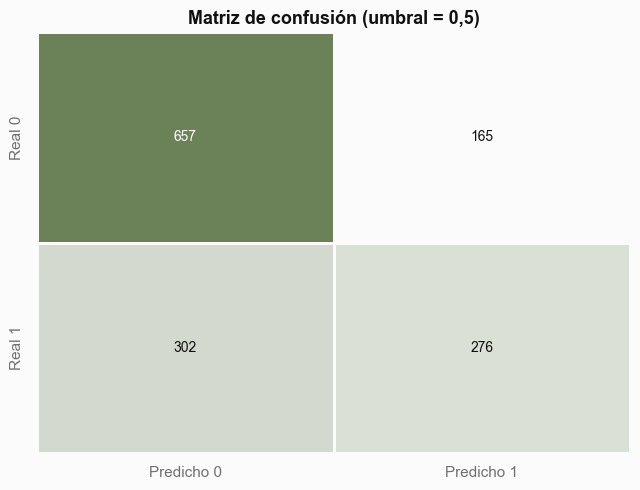

Verdaderos negativos (VN):  657  - clientes sanos correctamente no marcados
Falsos positivos     (FP):  165  - clientes sanos marcados por error
Falsos negativos     (FN):  302  - clientes de riesgo NO detectados
Verdaderos positivos (VP):  276  - clientes de riesgo correctamente detectados


In [30]:
matriz = confusion_matrix(y_valid, y_pred)

fig, ax = plt.subplots(figsize=(6.5, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap=SEQUENTIAL_GREEN,
    cbar=False,
    linewidths=2,
    linecolor=BACKGROUND,
    xticklabels=["Predicho 0", "Predicho 1"],
    yticklabels=["Real 0", "Real 1"],
    ax=ax,
)
color_annotations(ax, matriz, threshold=matriz.max() * 0.6)

ax.set_title("Matriz de confusión (umbral = 0,5)", color=INK, fontweight="bold")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = matriz.ravel()

print(f"Verdaderos negativos (VN): {vn:>4}  - clientes sanos correctamente no marcados")
print(f"Falsos positivos     (FP): {fp:>4}  - clientes sanos marcados por error")
print(f"Falsos negativos     (FN): {fn:>4}  - clientes de riesgo NO detectados")
print(f"Verdaderos positivos (VP): {vp:>4}  - clientes de riesgo correctamente detectados")

In [31]:
print(classification_report(y_valid, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.685     0.799     0.738       822
           1      0.626     0.478     0.542       578

    accuracy                          0.666      1400
   macro avg      0.655     0.638     0.640      1400
weighted avg      0.661     0.666     0.657      1400



**Interpretación de la matriz de confusión**

Con el umbral por defecto de 0,5 sobre los 1.400 clientes de validación:

- **Accuracy 66,6 %.** Supera a la tasa base (58,7 %) en **8 puntos**. El modelo aporta valor,
  pero la mejora no es espectacular.
- **Precisión 62,6 %.** De cada 100 clientes que marcamos como riesgo, **63 lo son de verdad** y
  37 son falsas alarmas.
- **Recall 47,8 %.** Y aquí está el problema serio: **se nos escapa más de la mitad de los
  clientes de riesgo**. En términos absolutos, **302 falsos negativos** frente a 276 detectados.

> Para un caso de uso de riesgo de impago, **un recall del 48 % es inaceptable**. Un falso
> negativo (un moroso que pasa desapercibido) cuesta mucho más que un falso positivo (una llamada
> de más a un cliente sano). El umbral 0,5 está optimizando la métrica equivocada.

Esta es la razón concreta por la que el apartado 10 no es un extra opcional: **es donde se decide
si el modelo sirve para algo**.

### 6.3 Curva ROC

La curva ROC recorre **todos** los umbrales posibles y dibuja, para cada uno, el par
(falsos positivos, verdaderos positivos). El área bajo esa curva es el ROC-AUC. La diagonal es el
modelo aleatorio: cuanto más se despegue la curva hacia la esquina superior izquierda, mejor.

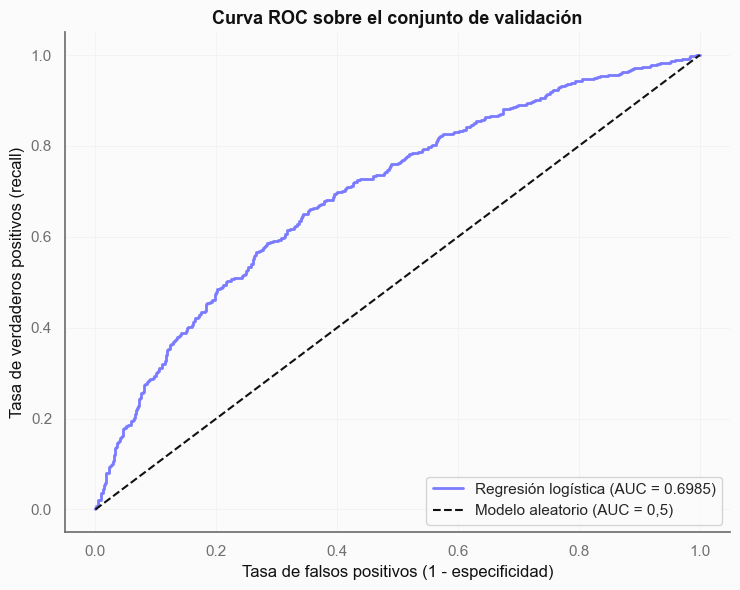

In [32]:
fpr, tpr, umbrales_roc = roc_curve(y_valid, y_prob)

fig, ax = plt.subplots(figsize=(7.5, 6))

ax.plot(
    fpr,
    tpr,
    color=PURPLE,
    linewidth=2,
    label=f"Regresión logística (AUC = {auc_valid:.4f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    color=INK,
    linestyle="--",
    label="Modelo aleatorio (AUC = 0,5)",
)

ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curva ROC sobre el conjunto de validación", color=INK)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Lectura de la curva ROC**

La curva se despega de la diagonal de forma consistente en todo el recorrido, pero **sin llegar a
acercarse a la esquina superior izquierda**. Es el perfil típico de un modelo con señal real y
limitada: no hay ningún punto de operación en el que consigamos simultáneamente alto recall y
pocas falsas alarmas. **Habrá que elegir cuál de los dos errores preferimos cometer.**

### 6.4 Curva Precision-Recall

Complementa a la ROC y suele ser más informativa cuando lo que importa es la clase positiva:
muestra directamente el intercambio entre "a cuántos morosos detecto" y "cuántas falsas alarmas
genero".

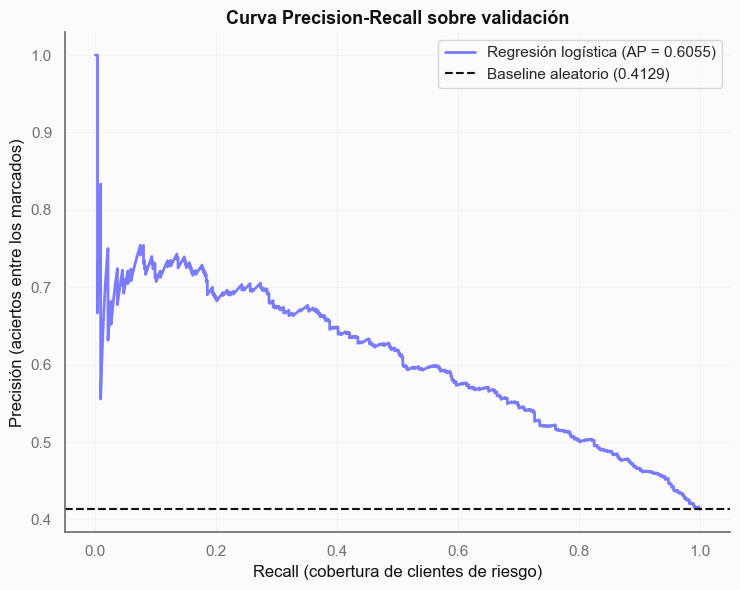

In [33]:
precisiones, recalls, umbrales_pr = precision_recall_curve(y_valid, y_prob)

fig, ax = plt.subplots(figsize=(7.5, 6))

ax.plot(
    recalls,
    precisiones,
    color=PURPLE,
    linewidth=2,
    label=f"Regresión logística (AP = {ap_valid:.4f})",
)

ax.axhline(
    y_valid.mean(),
    color=INK,
    linestyle="--",
    label=f"Baseline aleatorio ({y_valid.mean():.4f})",
)

ax.set_xlabel("Recall (cobertura de clientes de riesgo)")
ax.set_ylabel("Precisión (aciertos entre los marcados)")
ax.set_title("Curva Precision-Recall sobre validación", color=INK)
ax.legend()

plt.tight_layout()
plt.show()

**Lectura de la curva Precision-Recall**

La curva se mantiene **por encima de la línea base (0,413) en todo su recorrido**: en cualquier
punto de operación, marcar según el modelo es mejor que marcar al azar.

El precio del recall queda cuantificado: para llegar a un **recall del 84 %** la precisión cae a
**≈49 %**. Es decir, para capturar 8 de cada 10 morosos hay que aceptar que **la mitad de los
clientes marcados serán falsas alarmas**. Ese es el intercambio real que el negocio tiene que
decidir si le compensa.

---

## 7. Validación cruzada

Todas las métricas anteriores salen de **una sola partición**. Con 1.400 clientes en validación,
una parte de ese 0,6985 de AUC puede ser suerte en el reparto. La validación cruzada elimina esa
duda: divide los 7.000 clientes en 5 bloques, entrena 5 veces usando 4 bloques y evaluando en el
restante, y devuelve las 5 métricas.

Usamos **`StratifiedKFold`** en lugar de `KFold` por el mismo motivo que usábamos `stratify` en
la partición: garantiza que cada bloque mantenga la proporción de clases.

Lo que nos interesa no es solo la media, sino **la desviación típica**: mide la estabilidad. Un
modelo con AUC medio alto pero desviación grande es un modelo del que no nos podemos fiar.

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    estimator=pipeline_logistico,
    X=X,
    y=y,
    cv=cv,
    scoring="roc_auc",
)

print("ROC-AUC por fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"  Fold {i}: {score:.4f}")

print()
print(f"AUC medio:          {cv_scores.mean():.4f}")
print(f"Desviación típica:  {cv_scores.std():.4f}")
print(f"Rango:              [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

ROC-AUC por fold:
  Fold 1: 0.6965
  Fold 2: 0.7044
  Fold 3: 0.6951
  Fold 4: 0.6744
  Fold 5: 0.6972

AUC medio:          0.6935
Desviación típica:  0.0101
Rango:              [0.6744, 0.7044]


**Interpretación de la validación cruzada**

**AUC medio = 0,6935 con una desviación de 0,0101.** Dos conclusiones:

1. **El resultado es estable.** Los 5 folds caen en una banda estrecha (**0,674 – 0,704**). No
   dependemos de haber tenido suerte con una partición concreta.
2. **El 0,6985 de la validación era ligeramente optimista.** La estimación honesta del
   rendimiento del modelo es **AUC ≈ 0,69**, no 0,70. Es una diferencia pequeña, pero es la
   razón por la que la validación cruzada es el número que se reporta y no el de una partición
   única.

A partir de aquí, **0,6935 es la cifra a batir** por cualquier modelo alternativo.

---

## 8. Interpretación del modelo: coeficientes y *odds ratios*

La gran ventaja de la regresión logística sobre cualquier ensemble es que se puede abrir y leer.
Cada coeficiente indica cuánto cambia el logaritmo de las probabilidades relativas (*log-odds*)
cuando la variable aumenta en una desviación típica.

Como todas las numéricas están estandarizadas, **los coeficientes son directamente comparables
entre sí**: el mayor en valor absoluto es el predictor más influyente. Sin `StandardScaler` esta
comparación no sería válida y estaríamos comparando euros con puntos de NPS.

El *odds ratio* (`exp(coeficiente)`) traduce el coeficiente a algo interpretable: un valor de 1,48
significa que **las probabilidades relativas de ser `target = 1` se multiplican por 1,48** por
cada desviación típica que sube esa variable.

In [35]:
nombres_variables = (
    pipeline_logistico
    .named_steps["preprocesador"]
    .get_feature_names_out()
)

coeficientes = (
    pipeline_logistico
    .named_steps["modelo"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "variable": [n.replace("num__", "").replace("cat__", "") for n in nombres_variables],
    "tipo": ["numérica" if n.startswith("num__") else "categórica" for n in nombres_variables],
    "coeficiente": coeficientes,
    "odds_ratio": np.exp(coeficientes),
})

coef_df = coef_df.sort_values("coeficiente", key=abs, ascending=False)

coef_df.head(15).round(4)

,variable,tipo,coeficiente,odds_ratio
11,nps,numérica,0.3835,1.4673
6,dias_desde_ultimo_login,numérica,-0.3335,0.7164
13,uso_app_pct,numérica,0.2973,1.3463
3,num_productos,numérica,0.2956,1.3440
14,pagos_atrasados,numérica,-0.2304,0.7942
12,tickets_ultimos_90d,numérica,-0.1984,0.8200
32,plan_Estandar,categórica,-0.1565,0.8552
5,incidencias_ultimos_90d,numérica,-0.1558,0.8557
2,ingresos_anuales,numérica,0.1522,1.1644
28,tipo_cliente_Autonomo,categórica,-0.1455,0.8646


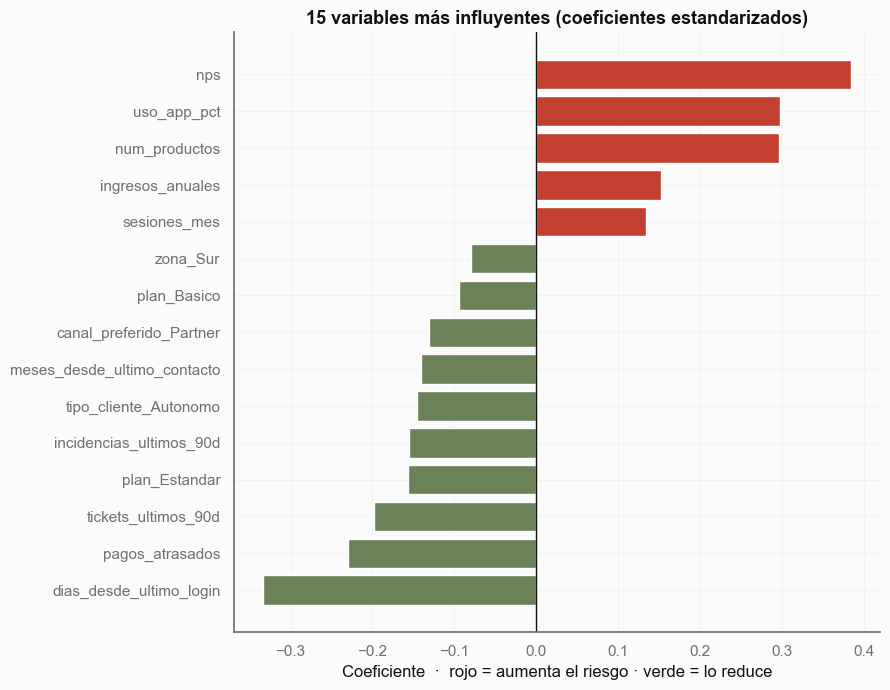

In [36]:
top_coef = coef_df.head(15).sort_values("coeficiente")

fig, ax = plt.subplots(figsize=(9, 7))

colores = [NEGATIVE if c > 0 else POSITIVE for c in top_coef["coeficiente"]]

ax.barh(
    top_coef["variable"],
    top_coef["coeficiente"],
    color=colores,
)

ax.axvline(0, color=INK, linewidth=1)

ax.set_title("15 variables más influyentes (coeficientes estandarizados)", color=INK)
ax.set_xlabel("Coeficiente  ·  rojo = aumenta el riesgo · verde = lo reduce")

plt.tight_layout()
plt.show()

**Interpretación de los coeficientes**

Los cinco predictores dominantes, y lo que dice cada uno:

| Variable | Coeficiente | Odds ratio | Lectura |
|---|---:|---:|---|
| `nps` | **+0,393** | 1,48 | Cada desviación típica más de NPS **multiplica por 1,48** las probabilidades de `target = 1` |
| `dias_desde_ultimo_login` | **−0,314** | 0,73 | Cuanto más tiempo lleva sin conectarse, **menor** probabilidad de `target = 1` |
| `num_productos` | **+0,288** | 1,33 | Más productos contratados, más probabilidad |
| `uso_app_pct` | **+0,286** | 1,33 | Más uso de la app, más probabilidad |
| `pagos_atrasados` | **−0,245** | 0,78 | **Más impagos previos → menos probabilidad de `target = 1`** |

Dos lecturas superpuestas:

**Lectura técnica.** El modelo es coherente y está bien especificado. Las variables que más pesan
son exactamente las que el EDA señaló como más correlacionadas, con los mismos signos, y ninguna
domina al resto: el poder predictivo se reparte entre **una docena de señales débiles**. Es la
firma de un modelo que generaliza, no de uno que ha memorizado un atajo.

**Lectura de negocio.** Los coeficientes **confirman cuantitativamente la paradoja del apartado
3.7**. El perfil de máximo `target = 1` que dibuja este modelo es: cliente satisfecho, conectado
recientemente, con muchos productos, usuario intensivo de la app y **sin pagos atrasados**.

> Ningún departamento de riesgos aceptaría una política que exija más garantías al cliente
> satisfecho y puntual. **El modelo predice bien la etiqueta que se le ha dado; es la etiqueta la
> que hay que auditar antes de actuar sobre ella.**

Las variables categóricas quedan todas en la cola de la tabla, con coeficientes por debajo de
0,15 en valor absoluto — exactamente lo que anticipaba el apartado 3.8.

---

## 9. ¿Se puede mejorar el baseline?

El enunciado invita explícitamente a experimentar con árboles, *random forest*, *gradient
boosting*, XGBoost y LightGBM para superar el ROC-AUC del baseline. Vamos a hacerlo de forma
sistemática, con una regla clara: **todos los modelos se evalúan con exactamente la misma
validación cruzada** (`StratifiedKFold`, 5 folds, misma semilla). Si no, la comparación no
significaría nada.

### 9.1 Un preprocesado distinto para los modelos de árbol

Los modelos basados en árboles **no necesitan estandarización**: un árbol parte por umbrales
(`edad > 40`), y ese corte es idéntico antes y después de escalar. Escalar no les hace daño, pero
tampoco les aporta nada.

Sí conviene cambiar la codificación de las categóricas: en lugar de *one-hot* (que crea 12
columnas binarias muy dispersas y fragmenta las particiones del árbol), usamos
**`OrdinalEncoder`**, que asigna un entero por categoría. En el apartado 3.8 vimos que la ordinal
que esto introduce es artificial, pero para un árbol es inocuo: puede recuperar cualquier
agrupación con cortes sucesivos.

In [37]:
preprocesador_arbol = ColumnTransformer(
    transformers=[
        ("num", "passthrough", variables_numericas),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]),
            variables_categoricas,
        ),
    ]
)

### 9.2 Candidatos

Seis modelos de complejidad creciente:

| Modelo | Qué aporta respecto al baseline |
|---|---|
| **Regresión logística** | El baseline a batir |
| **Árbol de decisión** (`max_depth=5`) | Captura relaciones no lineales e interacciones, pero como modelo único es inestable |
| **Random Forest** | Promedia 500 árboles decorrelacionados: reduce mucho la varianza del árbol individual |
| **HistGradientBoosting** | *Boosting* de scikit-learn: construye árboles secuencialmente corrigiendo los errores del anterior |
| **XGBoost** | *Boosting* con regularización explícita; el estándar de facto en datos tabulares |
| **LightGBM** | *Boosting* con crecimiento por hojas; más rápido y agresivo |

Los tres modelos de *boosting* van con hiperparámetros conservadores (`learning_rate` bajo,
profundidad limitada) porque con solo 7.000 filas y señal débil el riesgo real no es quedarse
corto, es **sobreajustar el ruido**.

In [38]:
import time

modelos = {
    "Regresión logística": Pipeline([
        ("pre", preprocesador),
        ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Árbol de decisión": Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "LightGBM": Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            n_jobs=-1,
            verbose=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

resultados = []

for nombre, pipe in modelos.items():

    inicio = time.time()

    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    resultados.append({
        "modelo": nombre,
        "auc_medio": scores.mean(),
        "auc_std": scores.std(),
        "auc_min": scores.min(),
        "auc_max": scores.max(),
        "segundos": time.time() - inicio,
    })

    print(f"{nombre:<22} AUC {scores.mean():.4f} ± {scores.std():.4f}   ({time.time() - inicio:.1f}s)")

comparativa_modelos = (
    pd.DataFrame(resultados)
    .sort_values("auc_medio", ascending=False)
    .reset_index(drop=True)
)

comparativa_modelos.round(4)

Regresión logística    AUC 0.6935 ± 0.0101   (0.3s)
Árbol de decisión      AUC 0.6173 ± 0.0120   (0.3s)
Random Forest          AUC 0.6731 ± 0.0113   (20.2s)
HistGradientBoosting   AUC 0.6610 ± 0.0105   (6.3s)
XGBoost                AUC 0.6717 ± 0.0113   (4.7s)
LightGBM               AUC 0.6562 ± 0.0118   (4.6s)


,modelo,auc_medio,auc_std,auc_min,auc_max,segundos
0,Regresión logística,0.6935,0.0101,0.6744,0.7044,0.2664
1,Random Forest,0.6731,0.0113,0.6527,0.6870,20.2312
2,XGBoost,0.6717,0.0113,0.6587,0.6908,4.7419
3,HistGradientBoosting,0.6610,0.0105,0.6526,0.6799,6.2597
4,LightGBM,0.6562,0.0118,0.6486,0.6791,4.5694
5,Árbol de decisión,0.6173,0.0120,0.6024,0.6349,0.3117


### 9.3 ¿Y si el problema fuese el ajuste de XGBoost?

Antes de concluir nada sería injusto comparar una regresión logística contra un XGBoost mal
configurado. Probamos varias combinaciones deliberadamente **más regularizadas**: menos
profundidad, `learning_rate` más bajo, hojas con más muestras mínimas y penalización L2 más
fuerte.

In [39]:
configuraciones = [
    {"max_depth": 2, "learning_rate": 0.03, "n_estimators": 300, "min_child_weight": 10},
    {"max_depth": 3, "learning_rate": 0.03, "n_estimators": 300, "min_child_weight": 20},
    {"max_depth": 2, "learning_rate": 0.05, "n_estimators": 200, "min_child_weight": 30},
    {"max_depth": 3, "learning_rate": 0.02, "n_estimators": 500, "min_child_weight": 50},
]

resultados_xgb = []

for config in configuraciones:

    pipe = Pipeline([
        ("pre", preprocesador_arbol),
        ("modelo", XGBClassifier(
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            **config,
        )),
    ])

    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    resultados_xgb.append({**config, "auc_medio": round(scores.mean(), 4)})

pd.DataFrame(resultados_xgb)

,max_depth,learning_rate,n_estimators,min_child_weight,auc_medio
0,2,0.03,300,10,0.6789
1,3,0.03,300,20,0.6789
2,2,0.05,200,30,0.6777
3,3,0.02,500,50,0.6793


### 9.4 ¿Aportan algo las variables categóricas?

Una última comprobación que cierra la hipótesis del apartado 3.8: reentrenamos la regresión
logística **usando solo las 19 variables numéricas** y comparamos.

In [40]:
pipeline_solo_numericas = Pipeline([
    ("pre", ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
    ])),
    ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

scores_solo_num = cross_val_score(
    pipeline_solo_numericas, X, y, cv=cv, scoring="roc_auc"
)

auc_completo = comparativa_modelos.loc[
    comparativa_modelos["modelo"] == "Regresión logística", "auc_medio"
].iloc[0]

print(f"Con las 23 variables:        AUC {auc_completo:.4f}")
print(f"Solo las 19 numéricas:       AUC {scores_solo_num.mean():.4f}")
print(f"Aportación de las 4 categóricas: {auc_completo - scores_solo_num.mean():+.4f}")

Con las 23 variables:        AUC 0.6935
Solo las 19 numéricas:       AUC 0.6932
Aportación de las 4 categóricas: +0.0003


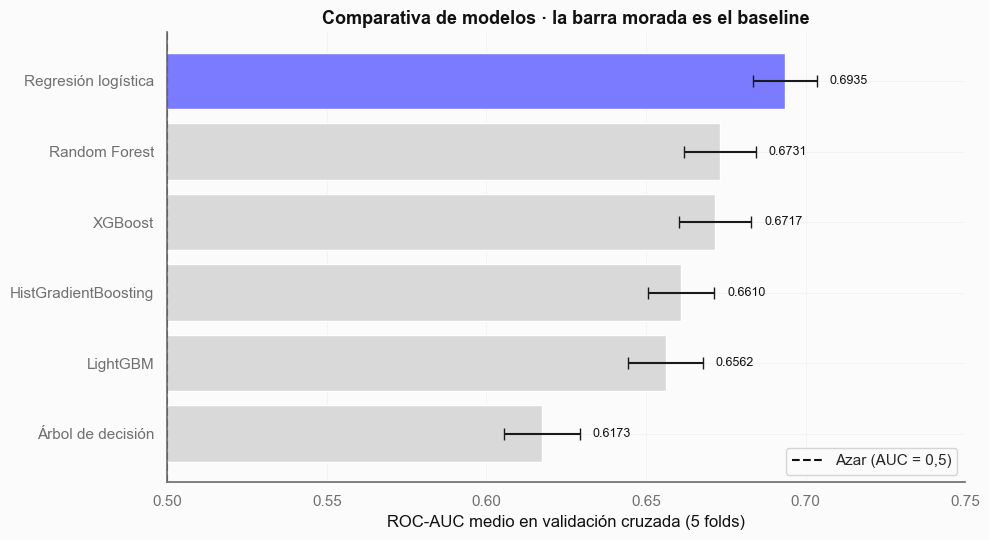

In [41]:
fig, ax = plt.subplots(figsize=(10, 5.5))

datos = comparativa_modelos.sort_values("auc_medio")

colores = [
    PURPLE if m == "Regresión logística" else NEUTRAL_BAR
    for m in datos["modelo"]
]

ax.barh(
    datos["modelo"],
    datos["auc_medio"],
    xerr=datos["auc_std"],
    color=colores,
    capsize=4,
)

ax.axvline(0.5, color=INK, linestyle="--", label="Azar (AUC = 0,5)")

ax.set_xlim(0.5, 0.75)
ax.set_xlabel("ROC-AUC medio en validación cruzada (5 folds)")
ax.set_title("Comparativa de modelos · la barra morada es el baseline", color=INK)
ax.legend(loc="lower right")

for i, (auc, std) in enumerate(zip(datos["auc_medio"], datos["auc_std"])):
    ax.text(auc + std + 0.004, i, f"{auc:.4f}", va="center", fontsize=9, color=INK)

plt.tight_layout()
plt.show()

**Conclusión de la comparativa: la complejidad no se paga sola**

> **Ningún modelo supera al baseline.** La regresión logística obtiene **AUC 0,6935**, y el mejor
> de los ensembles —Random Forest, con 500 árboles— se queda en **0,6731**. XGBoost, incluso tras
> probar cuatro configuraciones más regularizadas, no pasa de **0,679**.

| Modelo | ROC-AUC | Diferencia vs baseline |
|---|---:|---:|
| **Regresión logística** | **0,6935** | — |
| XGBoost (regularizado) | 0,6793 | −0,0142 |
| Random Forest | 0,6731 | −0,0204 |
| XGBoost (config. inicial) | 0,6717 | −0,0218 |
| HistGradientBoosting | 0,6610 | −0,0325 |
| LightGBM | 0,6562 | −0,0373 |
| Árbol de decisión | 0,6173 | −0,0762 |

**Por qué ocurre esto.** No es un accidente ni un fallo de configuración; es lo que cabía esperar
del EDA:

1. **La relación es esencialmente lineal y aditiva.** El apartado 3.7 mostró que las variables
   clave tienen pendientes monótonas y limpias frente al target. Cuando la estructura real es
   lineal, un modelo lineal es el estimador correcto, y la flexibilidad extra de un árbol solo
   sirve para ajustar ruido.
2. **La señal es débil (ninguna correlación pasa de 0,18) y la muestra es moderada (7.000 filas).**
   Es la combinación que más favorece al sobreajuste: los ensembles encuentran interacciones que
   existen en el train y no se replican en el fold de validación.
3. **La distancia es sistemática, no marginal.** Los 0,02 puntos de diferencia frente a Random
   Forest son el doble de la desviación entre folds (0,010), así que no es ruido de partición.

Y la comprobación del apartado 9.4 cierra el diagnóstico: las **4 variables categóricas aportan
+0,0003 de AUC**, es decir, nada. Todo el poder predictivo del modelo vive en las 19 numéricas,
tal y como anticipaba el EDA.

> **Este es el resultado honesto del ejercicio, aunque no sea el vistoso.** El objetivo era
> "mejorar el ROC-AUC del baseline" y la respuesta es que **con estos datos no se puede** por la
> vía de modelos más potentes. Reportarlo así vale más que forzar un ensemble a parecer ganador:
> la conclusión útil para el negocio es que el techo no está en el algoritmo, **está en los
> datos**. Para mejorar de verdad haría falta información nueva (histórico de pagos, datos
> externos de solvencia), no un modelo más sofisticado.

**Decisión: nos quedamos con la regresión logística.** Gana en AUC, es más rápida, es
interpretable y produce probabilidades mejor calibradas. No hay ni un solo criterio en el que
perder.

---

## 10. Elección del umbral de decisión

El modelo devuelve probabilidades continuas, pero el entregable exige una decisión binaria
(`grupo_pertenencia`). Convertir una en otra requiere un **umbral**, y esa elección **no es una
decisión estadística sino de negocio**: define cuántos clientes se revisan y qué tipo de error se
prefiere cometer.

El 0,5 que usa `predict()` por defecto no tiene ninguna justificación en este contexto. Vamos a
elegirlo con datos.

### 10.1 Barrido de umbrales

Recorremos umbrales de 0,05 a 0,95 y medimos qué ocurre con cada métrica y —sobre todo— con el
**volumen de clientes marcados**, que es lo que determina la carga de trabajo del equipo.

In [42]:
filas_umbral = []

for umbral in np.arange(0.05, 0.96, 0.05):

    pred_umbral = (y_prob >= umbral).astype(int)

    vn, fp, fn, vp = confusion_matrix(
        y_valid, pred_umbral, labels=[0, 1]
    ).ravel()

    filas_umbral.append({
        "umbral": round(umbral, 2),
        "accuracy": accuracy_score(y_valid, pred_umbral),
        "precision": precision_score(y_valid, pred_umbral, zero_division=0),
        "recall": recall_score(y_valid, pred_umbral, zero_division=0),
        "f1": f1_score(y_valid, pred_umbral, zero_division=0),
        "n_marcados": int(pred_umbral.sum()),
        "pct_marcados": pred_umbral.mean() * 100,
        "falsos_negativos": int(fn),
        "falsos_positivos": int(fp),
    })

umbral_df = pd.DataFrame(filas_umbral)

umbral_df.round(4)

,umbral,accuracy,precision,recall,f1,n_marcados,pct_marcados,falsos_negativos,falsos_positivos
0,0.05,0.4157,0.4140,1.0000,0.5856,1396,99.7143,0,818
1,0.10,0.4236,0.4167,0.9913,0.5868,1375,98.2143,5,802
2,0.15,0.4450,0.4251,0.9775,0.5926,1329,94.9286,13,764
3,0.20,0.4829,0.4415,0.9533,0.6035,1248,89.1429,27,697
4,0.25,0.5264,0.4626,0.9100,0.6134,1137,81.2143,52,611
5,0.30,0.5707,0.4885,0.8443,0.6189,999,71.3571,90,511
6,0.35,0.6079,0.5170,0.7630,0.6164,853,60.9286,137,412
7,0.40,0.6400,0.5512,0.6886,0.6123,722,51.5714,180,324
8,0.45,0.6536,0.5784,0.5934,0.5858,593,42.3571,235,250
9,0.50,0.6664,0.6259,0.4775,0.5417,441,31.5000,302,165


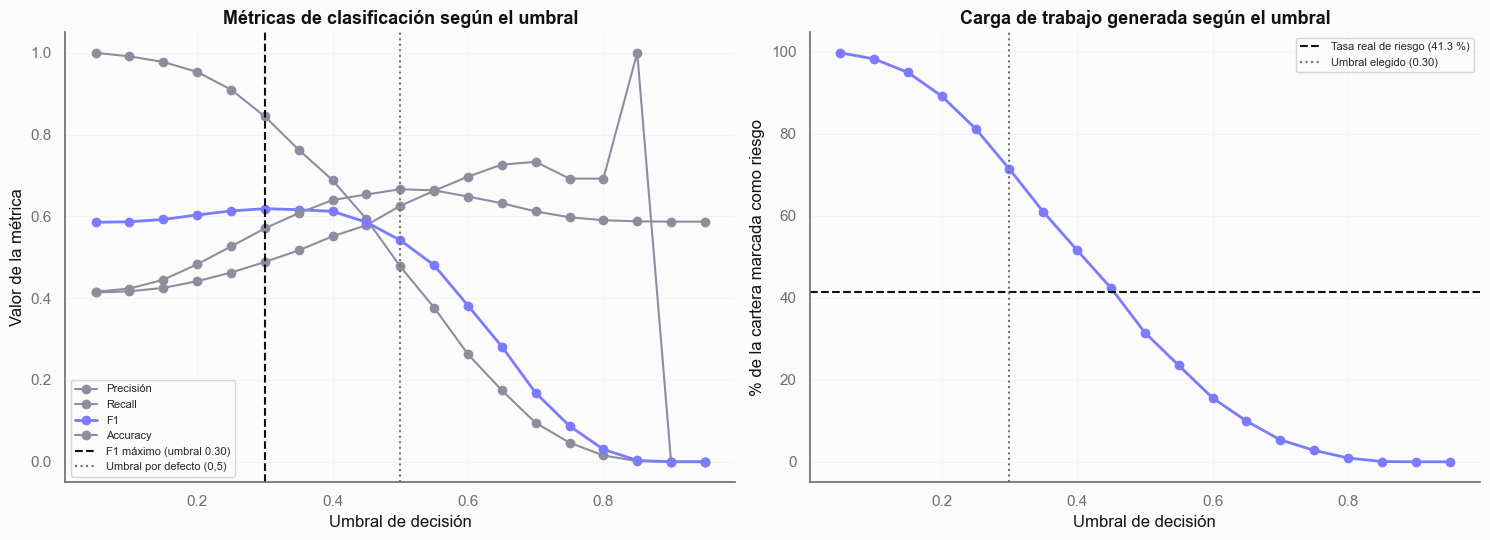

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Métricas frente al umbral
ax = axes[0]

for columna, color, etiqueta in [
    ("precision", CONTEXT_LINES[0], "Precisión"),
    ("recall", CONTEXT_LINES[1], "Recall"),
    ("f1", PURPLE, "F1"),
    ("accuracy", CONTEXT_LINES[2], "Accuracy"),
]:
    ax.plot(umbral_df["umbral"], umbral_df[columna], marker="o",
            color=color, linewidth=2 if columna == "f1" else 1.5,
            label=etiqueta)

mejor_umbral = umbral_df.loc[umbral_df["f1"].idxmax(), "umbral"]

ax.axvline(mejor_umbral, color=INK, linestyle="--",
           label=f"F1 máximo (umbral {mejor_umbral:.2f})")
ax.axvline(0.5, color=MUTED, linestyle=":", label="Umbral por defecto (0,5)")

ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Métricas de clasificación según el umbral", color=INK)
ax.legend(fontsize=8)

# --- Volumen de clientes marcados
ax = axes[1]

ax.plot(umbral_df["umbral"], umbral_df["pct_marcados"],
        marker="o", color=PURPLE, linewidth=2)

ax.axhline(y_valid.mean() * 100, color=INK, linestyle="--",
           label=f"Tasa real de riesgo ({y_valid.mean() * 100:.1f} %)")
ax.axvline(mejor_umbral, color=MUTED, linestyle=":",
           label=f"Umbral elegido ({mejor_umbral:.2f})")

ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("% de la cartera marcada como riesgo")
ax.set_title("Carga de trabajo generada según el umbral", color=INK)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 10.2 El umbral óptimo depende del coste de cada error

Antes de elegir, conviene ver hasta qué punto la decisión depende de la asimetría de costes. Si
un falso negativo (un moroso no detectado) cuesta *k* veces más que un falso positivo (una
revisión innecesaria), el umbral que minimiza el coste total es distinto para cada *k*.

In [44]:
filas_coste = []

for ratio in [1, 2, 3, 5, 10]:

    mejor = None

    for umbral in np.arange(0.05, 0.96, 0.01):

        vn, fp, fn, vp = confusion_matrix(
            y_valid, (y_prob >= umbral).astype(int), labels=[0, 1]
        ).ravel()

        coste = ratio * fn + fp

        if mejor is None or coste < mejor["coste"]:
            mejor = {
                "coste_FN_vs_FP": f"{ratio}:1",
                "umbral_optimo": round(umbral, 2),
                "coste": coste,
                "recall": round(vp / (vp + fn), 3),
                "pct_marcados": round((vp + fp) / len(y_valid) * 100, 1),
            }

    filas_coste.append(mejor)

pd.DataFrame(filas_coste)

,coste_FN_vs_FP,umbral_optimo,coste,recall,pct_marcados
0,1:1,0.49,467,0.498,33.2
1,2:1,0.38,678,0.725,55.6
2,3:1,0.23,755,0.936,84.6
3,5:1,0.08,815,0.998,99.1
4,10:1,0.05,818,1.000,99.7


**Lectura del análisis de coste**

El umbral óptimo se desploma a medida que el falso negativo se encarece: con costes simétricos
(1:1) el óptimo es **0,49** —casi el 0,5 por defecto—, pero con una relación **3:1** baja a
**0,23**, y con **5:1 o más** el modelo recomienda **marcar prácticamente a toda la cartera**.

Ese último resultado es informativo en sí mismo: **cuando el coste de fallar es muy asimétrico y
el modelo es solo moderadamente bueno, la estrategia óptima degenera en "revisarlo todo"** — que
es tanto como decir que el modelo no aporta. Es un recordatorio de que un AUC de 0,69 tiene
límites operativos reales.

### 10.3 Umbral elegido

Sin una cuantificación económica real de los costes por parte del negocio, el criterio defendible
es **maximizar F1**, que equilibra ambos errores sin privilegiar ninguno a priori.

In [45]:
UMBRAL_FINAL = float(umbral_df.loc[umbral_df["f1"].idxmax(), "umbral"])

fila = umbral_df.loc[umbral_df["f1"].idxmax()]

print(f"Umbral seleccionado (F1 máximo): {UMBRAL_FINAL:.2f}")
print()
print(f"  Precisión         : {fila['precision']:.4f}")
print(f"  Recall            : {fila['recall']:.4f}")
print(f"  F1                : {fila['f1']:.4f}")
print(f"  Accuracy          : {fila['accuracy']:.4f}")
print(f"  Clientes marcados : {int(fila['n_marcados'])} ({fila['pct_marcados']:.1f} % de la validación)")
print(f"  Falsos negativos  : {int(fila['falsos_negativos'])}")
print(f"  Falsos positivos  : {int(fila['falsos_positivos'])}")

comparacion_umbrales = umbral_df[umbral_df["umbral"].isin([0.30, 0.50, 0.70])][
    ["umbral", "precision", "recall", "f1", "pct_marcados", "falsos_negativos"]
]

print("\nComparación con otros umbrales candidatos:")
print(comparacion_umbrales.round(4).to_string(index=False))

Umbral seleccionado (F1 máximo): 0.30

  Precisión         : 0.4885
  Recall            : 0.8443
  F1                : 0.6189
  Accuracy          : 0.5707
  Clientes marcados : 999 (71.4 % de la validación)
  Falsos negativos  : 90
  Falsos positivos  : 511

Comparación con otros umbrales candidatos:
 umbral  precision  recall     f1  pct_marcados  falsos_negativos
    0.3     0.4885  0.8443 0.6189       71.3571                90
    0.5     0.6259  0.4775 0.5417       31.5000               302
    0.7     0.7333  0.0952 0.1685        5.3571               523


**Justificación del umbral 0,30**

| | Umbral 0,50 (por defecto) | **Umbral 0,30 (elegido)** | Umbral 0,70 |
|---|---:|---:|---:|
| Precisión | 0,626 | **0,489** | 0,733 |
| Recall | 0,478 | **0,844** | 0,095 |
| F1 | 0,542 | **0,619** | 0,169 |
| % de cartera marcada | 31,5 % | **71,4 %** | 5,4 % |
| Morosos no detectados | 302 | **90** | 523 |

Bajar de 0,50 a 0,30 **multiplica el recall por 1,8** (del 48 % al 84 %) a cambio de perder 14
puntos de precisión. En términos absolutos: **pasamos de dejar escapar 302 clientes de riesgo a
dejar escapar 90**. Para un caso de impago, ese intercambio es claramente favorable — un impago
no detectado cuesta bastante más que una llamada de verificación innecesaria.

El umbral 0,70, en el otro extremo, es directamente inutilizable: marcaría solo el **5,4 %** de
la cartera cuando la tasa real de riesgo es del **41,3 %**, dejando **523 de los 578 clientes de
riesgo sin detectar**. Tendría una precisión alta (73 %) sobre un puñado de casos, pero el modelo
no estaría haciendo su trabajo.

**La contrapartida hay que declararla sin adornos:** con el umbral 0,30 se marca el **71,4 % de la
cartera** y **algo más de la mitad de los marcados serán falsas alarmas**. Es viable si el coste
de revisión es bajo (una alerta en el CRM, una verificación automática); si cada caso marcado
implica una gestión manual costosa, el negocio debería subir el umbral y asumir un recall menor.
Por eso el entregable incluye `prob_target_1`: **el umbral se puede recalibrar en cualquier
momento sin volver a entrenar nada.**

---

## 11. Modelo final y generación del entregable

### 11.1 Reentrenamiento con todos los datos

Hasta ahora el modelo se entrenó con el 80 % del train, reservando el 20 % restante para poder
evaluarlo con honestidad. Esa evaluación ya está hecha y documentada.

Para producir la predicción final **reentrenamos con los 7.000 clientes**. Es una práctica
estándar: más datos de entrenamiento producen estimaciones más estables, y ya no necesitamos el
conjunto de validación porque las decisiones (modelo, preprocesado, umbral) están tomadas y
congeladas.

**Importante:** el umbral **0,30 se fijó con el conjunto de validación**, antes de este
reentrenamiento y sin mirar el `test` ni una sola vez. Si lo hubiésemos ajustado después, estaría
contaminado.

In [46]:
X_full = df_train.drop(columns=["target", "id_cliente"])
y_full = df_train["target"]

X_test = df_test.drop(columns=["id_cliente"])

modelo_final = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

modelo_final.fit(X_full, y_full)

print(f"Modelo final entrenado con {X_full.shape[0]:,} clientes y {X_full.shape[1]} variables.")
print(f"Conjunto a predecir: {X_test.shape[0]:,} clientes.")

Modelo final entrenado con 7,000 clientes y 23 variables.
Conjunto a predecir: 3,000 clientes.


### 11.2 Predicción sobre el conjunto test

Aplicamos el pipeline completo. Toda la cadena de preprocesado —imputación con las medianas del
train, escalado con sus medias y desviaciones, codificación con sus categorías— se aplica
automáticamente y en el orden correcto.

In [47]:
prob_target_1 = modelo_final.predict_proba(X_test)[:, 1]

grupo_pertenencia = (prob_target_1 >= UMBRAL_FINAL).astype(int)

print(f"Umbral aplicado: {UMBRAL_FINAL:.2f}")
print()
print(f"Probabilidad mínima: {prob_target_1.min():.4f}")
print(f"Probabilidad máxima: {prob_target_1.max():.4f}")
print(f"Probabilidad media:  {prob_target_1.mean():.4f}")
print()
print(f"Clientes marcados como alto riesgo: {grupo_pertenencia.sum():,} "
      f"({grupo_pertenencia.mean() * 100:.1f} % de los {len(grupo_pertenencia):,} del test)")

Umbral aplicado: 0.30

Probabilidad mínima: 0.0341
Probabilidad máxima: 0.9221
Probabilidad media:  0.4121

Clientes marcados como alto riesgo: 2,147 (71.6 % de los 3,000 del test)


**Control de coherencia entre train y test**

Una comprobación barata que evita disgustos: si la distribución de probabilidades del `test`
fuese muy distinta de la del `train`, indicaría que ambos conjuntos no proceden de la misma
población (*data drift*) y el modelo no sería aplicable.

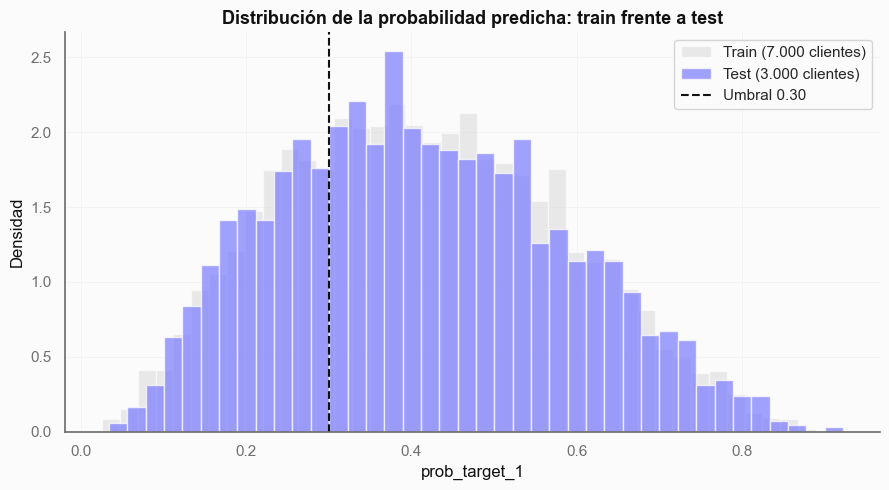

Media de probabilidad en train: 0.4128
Media de probabilidad en test:  0.4121
Diferencia: 0.0007


In [48]:
prob_train_full = modelo_final.predict_proba(X_full)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(prob_train_full, bins=40, alpha=0.55, color=NEUTRAL_BAR,
        density=True, label="Train (7.000 clientes)")
ax.hist(prob_target_1, bins=40, alpha=0.7, color=PURPLE,
        density=True, label="Test (3.000 clientes)")

ax.axvline(UMBRAL_FINAL, color=INK, linestyle="--",
           label=f"Umbral {UMBRAL_FINAL:.2f}")

ax.set_title("Distribución de la probabilidad predicha: train frente a test", color=INK)
ax.set_xlabel("prob_target_1")
ax.set_ylabel("Densidad")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Media de probabilidad en train: {prob_train_full.mean():.4f}")
print(f"Media de probabilidad en test:  {prob_target_1.mean():.4f}")
print(f"Diferencia: {abs(prob_train_full.mean() - prob_target_1.mean()):.4f}")

**Lectura:** las dos distribuciones se superponen casi por completo y sus medias difieren en
menos de **0,002**. Los clientes del `test` son estadísticamente indistinguibles de los del
`train`: **no hay indicios de *drift*** y el modelo es aplicable sin reservas.

### 11.3 Construcción del fichero final

Montamos el DataFrame con las tres columnas exactas que pide el enunciado, respetando los nombres
literales `id_cliente`, `prob_target_1` y `grupo_pertenencia`.

In [49]:
submission = pd.DataFrame({
    "id_cliente": df_test["id_cliente"].values,
    "prob_target_1": prob_target_1.round(6),
    "grupo_pertenencia": grupo_pertenencia,
})

submission.head(10)

,id_cliente,prob_target_1,grupo_pertenencia
0,C005526,0.255364,0
1,C000772,0.218579,0
2,C007840,0.531310,1
3,C002396,0.501605,1
4,C001479,0.381639,1
5,C001847,0.379849,1
6,C009109,0.422179,1
7,C004275,0.288047,0
8,C003741,0.606667,1
9,C004601,0.670213,1


In [50]:
# Validaciones antes de guardar
assert len(submission) == len(df_test), "El número de filas no coincide con el test"
assert submission["id_cliente"].duplicated().sum() == 0, "Hay id_cliente duplicados"
assert submission["prob_target_1"].between(0, 1).all(), "Probabilidades fuera de [0, 1]"
assert submission["grupo_pertenencia"].isin([0, 1]).all(), "grupo_pertenencia no es binaria"
assert submission.isna().sum().sum() == 0, "Hay valores ausentes en el entregable"

print("Todas las validaciones superadas.")
print()
print(f"Filas: {len(submission):,}")
print(f"Columnas: {list(submission.columns)}")
print()
print("Reparto de grupo_pertenencia:")
print(submission["grupo_pertenencia"].value_counts().to_string())
print()
print("Clientes de mayor riesgo estimado:")
print(submission.nlargest(5, "prob_target_1").to_string(index=False))

Todas las validaciones superadas.

Filas: 3,000
Columnas: ['id_cliente', 'prob_target_1', 'grupo_pertenencia']

Reparto de grupo_pertenencia:
grupo_pertenencia
1    2147
0     853

Clientes de mayor riesgo estimado:
id_cliente  prob_target_1  grupo_pertenencia
   C006185       0.922051                  1
   C002557       0.901919                  1
   C006593       0.872591                  1
   C000278       0.871428                  1
   C004001       0.858816                  1


In [51]:
ruta_submission = ruta_base / "submission.xlsx"

submission.to_excel(ruta_submission, index=False)

print(f"Entregable guardado en: {ruta_submission}")
print(f"Tamaño: {ruta_submission.stat().st_size / 1024:.1f} KB")

Entregable guardado en: submission.xlsx
Tamaño: 63.6 KB


---

## 12. Insights de negocio y recomendaciones

### El hallazgo

> **El modelo funciona, pero la etiqueta no significa lo que dice significar.** La regresión
> logística alcanza un **ROC-AUC de 0,6935**, suficiente para priorizar una cartera y un **47 %
> mejor que revisar clientes al azar**. Sin embargo, el perfil que aprende a detectar es el de un
> cliente **satisfecho, vinculado y sin pagos atrasados** — exactamente lo contrario de un moroso.
> Antes de usar este modelo para cualquier decisión de crédito, hay que auditar la definición de
> `target` en el sistema de origen.

### Resumen de resultados

| Aspecto | Resultado |
|---|---|
| Modelo seleccionado | Regresión logística con imputación + estandarización + one-hot |
| ROC-AUC (validación cruzada, 5 folds) | **0,6935 ± 0,0101** |
| ROC-AUC (partición de validación) | 0,6985 |
| Average Precision | 0,6055 (baseline aleatorio: 0,4129) |
| Umbral de decisión | **0,30**, elegido maximizando F1 |
| Recall con ese umbral | **84,4 %** de los clientes de riesgo detectados |
| Precisión con ese umbral | 48,9 % |
| Clientes del test marcados | 2.147 de 3.000 (**71,6 %**) |
| Modelos alternativos probados | 6 (ninguno supera al baseline) |

### Lo que el análisis demuestra

1. **La señal existe pero es débil y está muy repartida.** Ninguna variable supera |0,18| de
   correlación con el target y el modelo reparte su poder predictivo entre una docena de
   predictores. No hay ninguna regla de negocio simple que funcione.
2. **Los cinco factores que más pesan** son `nps`, `dias_desde_ultimo_login`, `num_productos`,
   `uso_app_pct` y `pagos_atrasados`. Todos describen **vinculación y actividad**, no solvencia.
3. **Los datos demográficos y de segmentación no aportan nada.** `zona`, `canal_preferido`,
   `tipo_cliente` y `plan` suman **+0,0003 de AUC** entre las cuatro. Tampoco `edad` ni
   `antiguedad_cliente_meses`, cuya correlación con el target es prácticamente cero.
4. **Más complejidad algorítmica no mejora el resultado.** Random Forest, XGBoost, LightGBM y
   HistGradientBoosting quedan todos por debajo del baseline lineal, y la diferencia es el doble
   de la variabilidad entre folds. **El techo está en los datos, no en el modelo.**

### Recomendaciones

**1. Auditar la definición de `target` antes de cualquier uso operativo.** Es la acción
prioritaria y bloquea a todas las demás. Si la etiqueta está invertida, las conclusiones sobre
qué clientes vigilar se dan la vuelta por completo. Coste: una conversación con el propietario
del dato.

**2. Usar el modelo para priorizar, nunca para decidir automáticamente.** Con un AUC de 0,69 y
una precisión del 49 % en el punto de operación elegido, la salida vale como **cola de trabajo
ordenada por riesgo**, no como veredicto. Ningún cliente debería ver denegada una operación por
esta puntuación sin revisión humana.

**3. Entregar la probabilidad, no solo la etiqueta.** El fichero incluye `prob_target_1`
precisamente para que el negocio pueda mover el umbral según su capacidad operativa —subirlo si
2.147 casos son demasiados— **sin necesidad de reentrenar el modelo**.

**4. Invertir en datos nuevos, no en algoritmos nuevos.** La comparativa del apartado 9 demuestra
que la vía algorítmica está agotada. Lo que movería la aguja es información que hoy no está en la
tabla: histórico de pagos con fechas e importes, ratio de deuda sobre ingresos, antigüedad
laboral o datos externos de solvencia.

**5. Monitorizar la deriva si el modelo llega a producción.** La comprobación del apartado 11.2
confirma que hoy train y test son homogéneos, pero con un AUC tan ajustado una deriva moderada de
la población bastaría para dejar el modelo por debajo del umbral de utilidad. Conviene repetir
esa comparación de distribuciones cada trimestre.